## Loading and Understanding Dataset
Data sourced from https://www.kaggle.com/datasets/osmi/mental-health-in-tech-2016

In [2]:
#import libraries
import pandas as pd
import os

# Load your dataset
df= pd.read_csv('../data/mental-heath-in-tech-2016_20161114.csv')
# Check the first few rows of the dataset
df.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


## Data Undesrtanding & preprocessing

In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1146 non-null   object 
 2   Is your employer primarily a tech company/organization?     

(1433, 63)

In [4]:
# Basic info (check for missing values and data types)
print(df.to_string(index=False))
# Get descriptive statistics for numerical columns
df.describe()

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



,Are you self-employed?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you have previous employers?,Have you ever sought treatment for a mental health issue from a mental health professional?,What is your age?
count,1433.000000,1146.000000,263.000000,287.000000,1433.000000,1433.000000,1433.000000
mean,0.200279,0.770506,0.942966,0.644599,0.882066,0.585485,34.286113
std,0.400349,0.420691,0.232350,0.479471,0.322643,0.492810,11.290931
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,28.000000
50%,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,33.000000
75%,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,39.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,323.000000


In [5]:
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

1. Are you self-employed?
2. How many employees does your company or organization have?
3. Is your employer primarily a tech company/organization?
4. Is your primary role within your company related to tech/IT?
5. Does your employer provide mental health benefits as part of healthcare coverage?
6. Do you know the options for mental health care available under your employer-provided coverage?
7. Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
8. Does your employer offer resources to learn more about mental health concerns and options for seeking help?
9. Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?
10. If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
11. Do you think that discussing a mental health disorder with your employer would have negative c

## Rename columns
Renamed the columns in the survey dataset to improve clarity, consistency, and usability throughout the analysis. The original column names are lengthy, inconsistent, or contained special characters and spaces, which can make coding cumbersome and error-prone.

In [6]:
# Column names you provided earlier
columns_new_complete = [

  'Self Employed',
  'Company Size',
  'tech company Flag',
  'Tech Role',
  'MH Coverage',
  'MH Coverage Awareness',
  'MH Employer Discussion',
  'MH Resources Provided',
  'MH Anonymity',
  'Medical Leave',
  'MH Discussion Neg Impact',
  'PH Discussion Neg Impact',
  'MH Discussion Coworkers',
  'MH Discussion Supervisor(s)',
  'MH vs PH Employer',
  'MH Consequence Coworkers',
  'MH Coverage (Private or State)',
  'MH Resource Knowledge (local or online)',
  'MH Reveal to Clients/Business',
  'MH Client/Business Impact',
  'MH Reveal to Coworkers/employees',
  'MH Coworker Neg Impact',
  'MH Productivity Affected',
  'MH Productivity %',
  'Previous Employers',
  'Previous MH Benefits',
  'Previous MH Awareness',
  'Previous MH Discussion',
  'Previous MH Resources Provided',
  'Previous MH Anonymity',
  'Previous MH Discussion Neg Impact',
  'Previous PH Discussion Neg Impact',
  'Previous MH Discussion Coworkers',
  'Previous MH Discussion Supervisor(s)',
  'Previous MH vs PH',
  'Previous MH Coworkers Reveal Neg',
  'PH In Interview',
  'Why/ Why Not_ph',
  'MH In Interview',
  'Why/Why Not_mh',
  'MH Bad Impact on Career',
  'MH Neg View of team members/Coworkers',
  'MH Sharing with Family/Friends',
  'MH Bad Response',
  'Less Reveal MH After Observation',
  'MH Family History',
  'Past MH Disorder',
  'Current MH Disorder',
  'MH Diagnosed Conditions',
  'MH Self-believed Conditions',
  'MH Diagnosed by Professional',
  'MH Diagnosed Conditions',
  'MH Sought Professional Treatment',
  'MH Effective Treatment Impact',
  'MH NOT Effective Treatment Impact',
  'Age',
  'Gender',
  'Living Country',
  'Living US State',
  'Working Country',
  'Working US State',
  'Work Position',
  'Remote Work',
]

# Ensure the correct number of columns
if len(df.columns) == len(columns_new_complete):
    df.columns = columns_new_complete
else:
    print("Mismatch in column length!")
    # Optionally print lengths for debugging
    print(f"DataFrame Columns: {len(df.columns)}")
    print(f"New Columns: {len(columns_new_complete)}")
    df.columns = columns_new_complete  # full list of 63
#df.drop(columns=columns_to_drop, inplace=True)


## Missing values
 Check columns with more than 30% missing values

Columns to drop (>30% missing): 15 out of 63 total columns


/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/1717691807.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Missing Proportion', y='Column', data=missing_df, palette="flare")


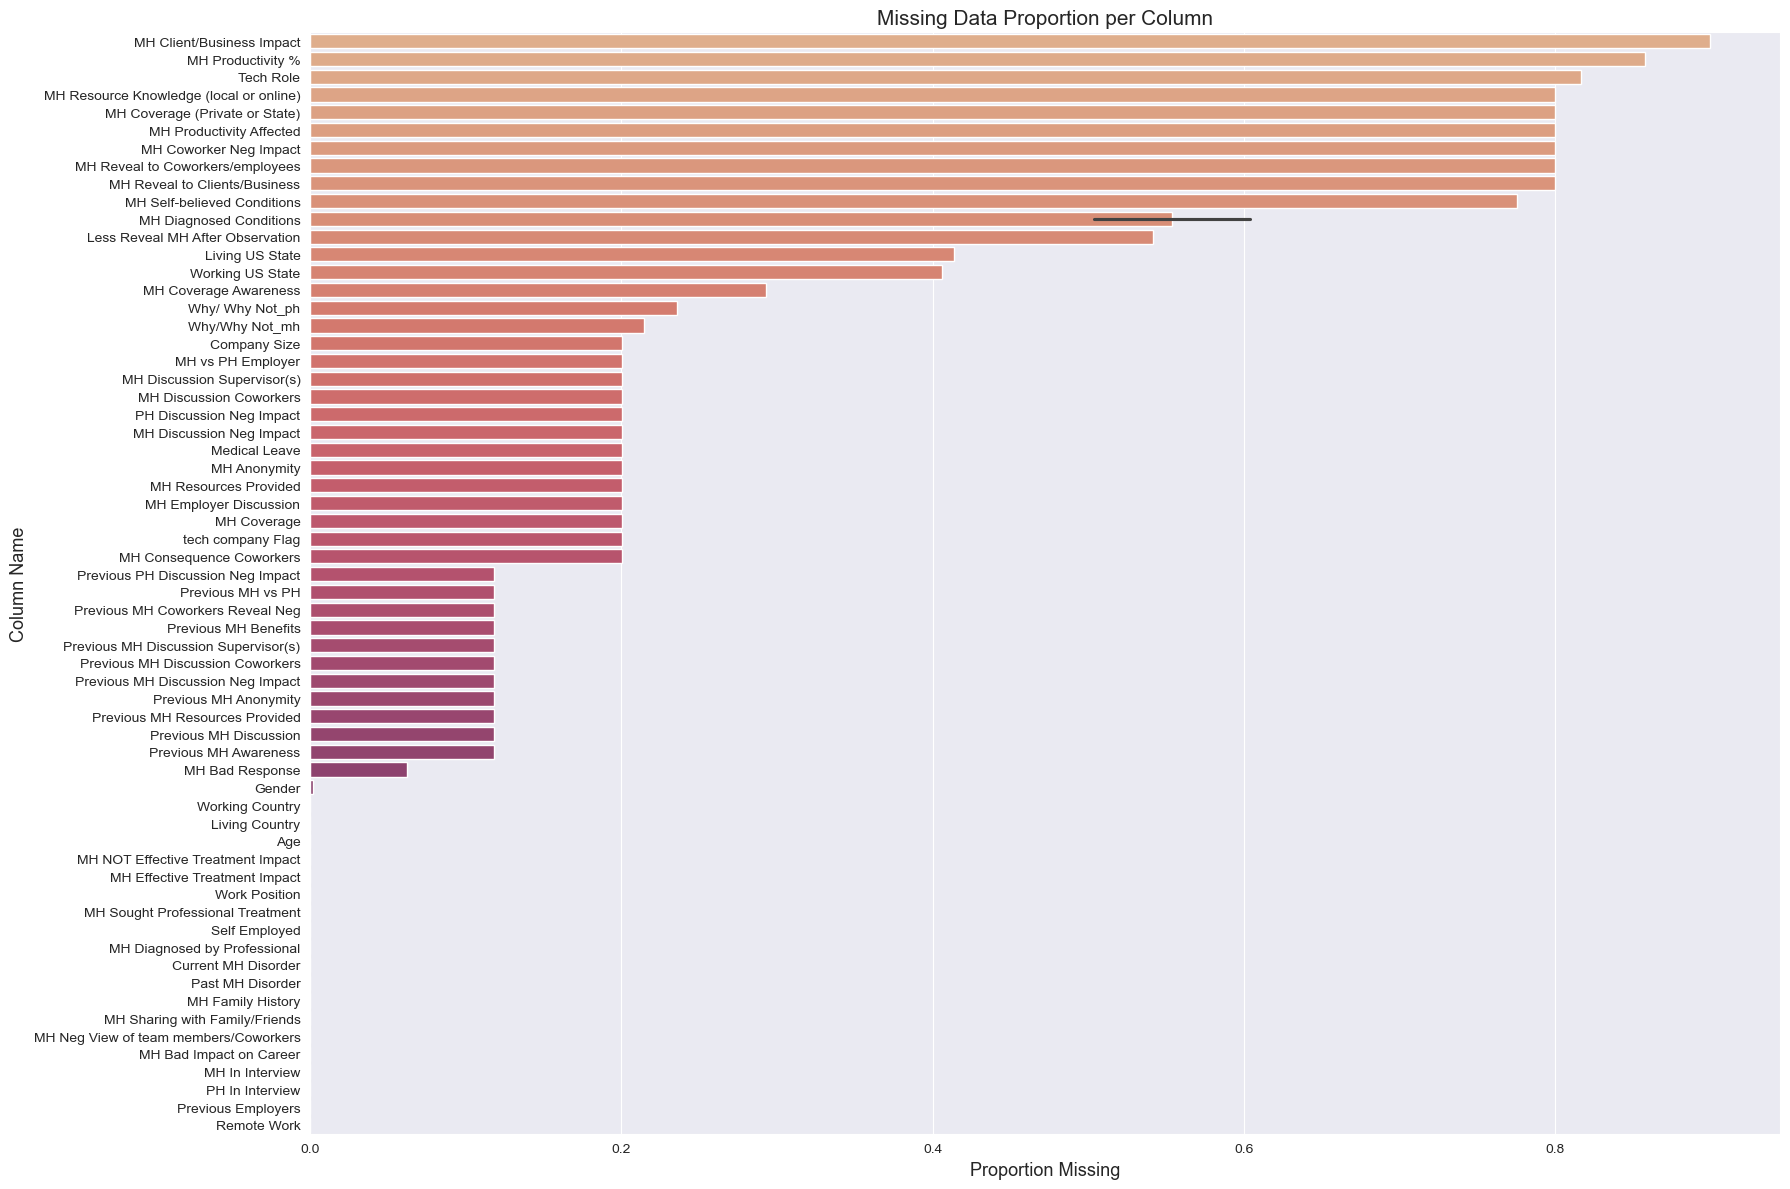

In [7]:
# Check how many columns have >30% missing
high_missing = df.isna().mean() > 0.3
num_to_drop = high_missing.sum()

print(f"Columns to drop (>30% missing): {num_to_drop} out of {df.shape[1]} total columns")

# Calculate missing percentages
missing_pct = df.isna().mean().sort_values(ascending=False)

# Calculate missing percentages
missing_pct = df.isna().mean().sort_values(ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')  # Ensure white background

# Calculate missing percentages
missing_pct = df.isna().mean().sort_values(ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reset Seaborn style to whitegrid for clean background
sns.set_style("darkgrid")

# Prepare DataFrame for plotting
missing_df = pd.DataFrame({
    'Column': missing_pct.index,
    'Missing Proportion': missing_pct.values
})

# Set the figure size
plt.figure(figsize=(18, 12))

# Create horizontal bar plot from bottom to top
sns.barplot(x='Missing Proportion', y='Column', data=missing_df, palette="flare")

# Add labels and title
plt.xlabel("Proportion Missing", fontsize=13)
plt.ylabel("Column Name", fontsize=13)
plt.title("Missing Data Proportion per Column", fontsize=15)

output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)

plot_path = os.path.join(output_dir, "missing_data_proportion.png")

# Display the plot
plt.tight_layout()
plt.show()

In [8]:
cols_to_drop = df.columns[df.isna().mean() > 0.3]
df.drop(cols_to_drop, axis=1, inplace=True)
len(df.columns)

48

 **Imputation of missing values:**
To handle missing entries in the dataset, we use mode imputation, replacing NaNs with the most frequent value in each column.
This approach is suitable for categorical or discrete data where the most common response is a reasonable substitute.

In [9]:
import numpy as np
from sklearn.impute import SimpleImputer

mode_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
mode_imputer.fit(df)
processed_data = mode_imputer.transform(df)
df_processed = pd.DataFrame(data=processed_data, columns=df.columns)

In [10]:
df.shape

(1433, 48)

## Age

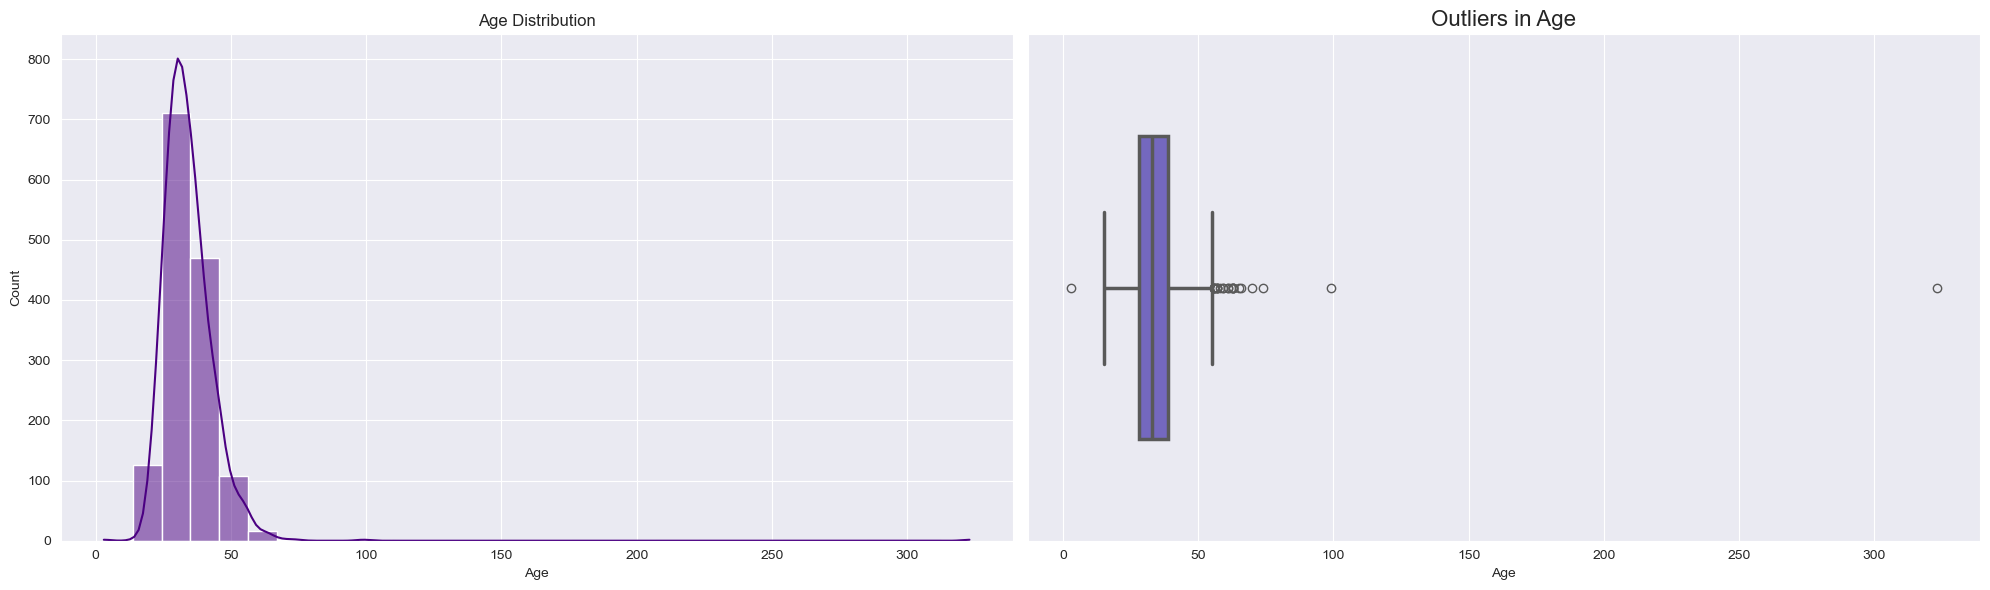

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with two subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(20, 6))  # Adjust the figure size

# Plot the histogram on the first subplot
sns.histplot(df['Age'], bins=30, kde=True, color='#4B0082', ax=ax[0])
ax[0].set_title('Age Distribution')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Count')

# Plot the boxplot on the second subplot
sns.set_style("darkgrid")
sns.boxplot(data=df['Age'],color='slateblue', orient='h', linewidth=2.5, width=0.6, ax=ax[1])
ax[1].set_title('Outliers in Age', fontsize=16)

# Adjust layout for better spacing
plt.tight_layout()

#save img
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)

plot_path = os.path.join(output_dir, "age_proportion_outliers.png")

# Display the plots
plt.show()

## Cleaned Age

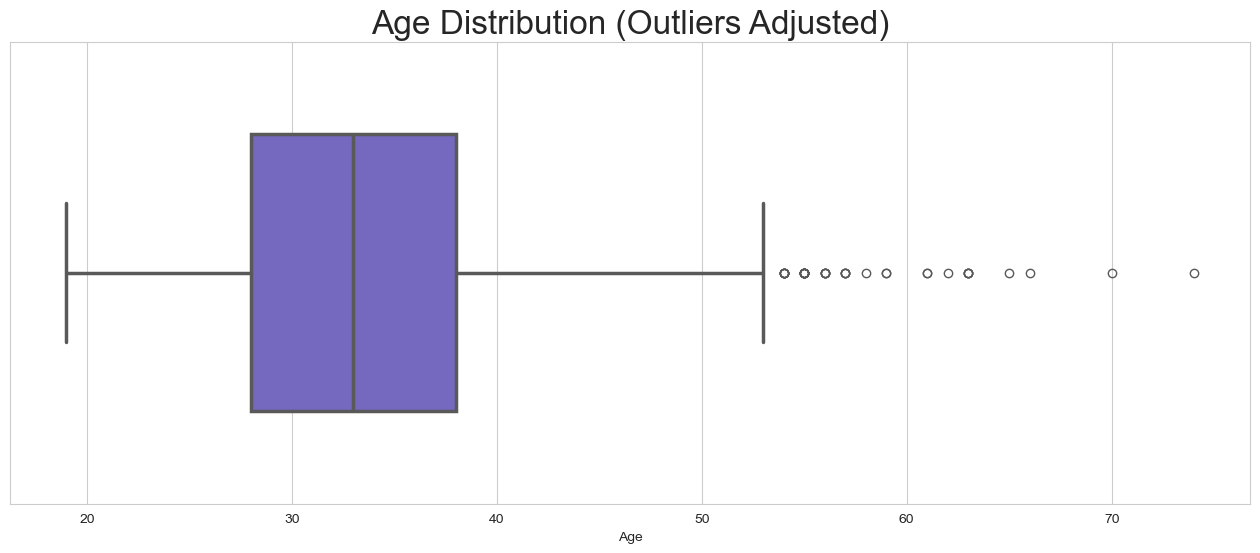

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure 'Age' is numeric (in case it was imputed as string/object)
df_processed['Age'] = pd.to_numeric(df_processed['Age'], errors='coerce')

# Define valid age range (18 to 75)
valid_age_mask = (df_processed['Age'] >= 18) & (df_processed['Age'] <= 75)

# Compute the mean of valid ages
valid_mean = round(df_processed.loc[valid_age_mask, 'Age'].mean())

# Replace outlier ages (<18 or >75) with the valid mean
df_processed.loc[~valid_age_mask, 'Age'] = valid_mean

# Plot boxplot of the adjusted age distribution
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

ax = sns.boxplot(data=df_processed['Age'], color='slateblue', orient='h', linewidth=2.5, width=0.6)
ax.set_title('Age Distribution (Outliers Adjusted)', fontsize=24)

#save img
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)

plot_path = os.path.join(output_dir, "age_outliers_adjust.png")

plt.show()

## Age Group

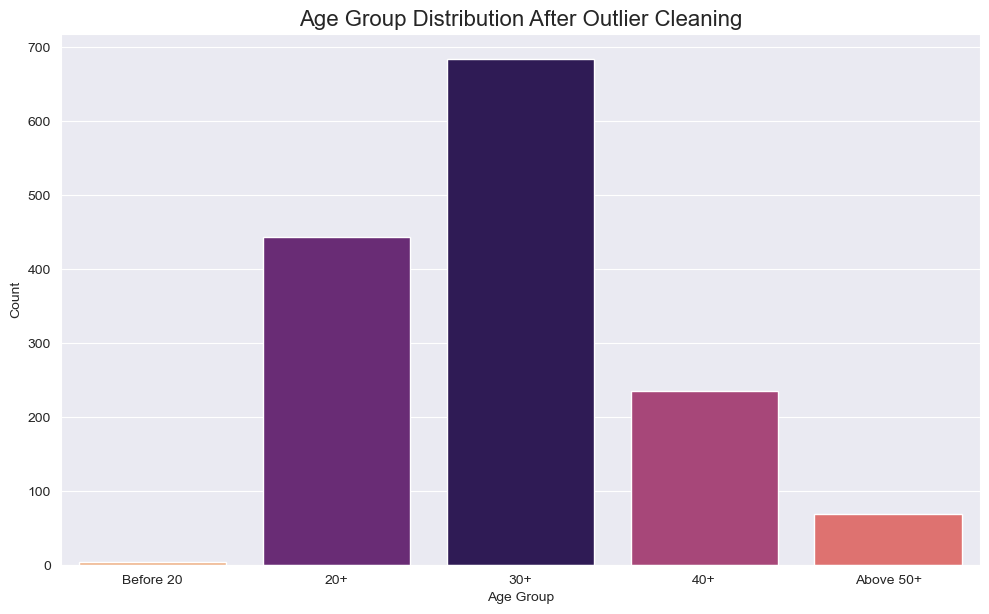

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Clean outliers on df_processed
df_processed = df_processed[df_processed['Age'].notna()]  # remove NaNs if needed
df_processed['Age'] = df_processed['Age'].apply(
    lambda x: round(df_processed[(df_processed['Age'] >= 18) & (df_processed['Age'] <= 75)]['Age'].mean())
    if x < 18 or x > 75 else x
)

# Step 2: Define age group function
def categorize_age(age):
    if 17 <= age < 20:
        return 'Before 20'
    elif 20 <= age < 30:
        return '20+'
    elif 30 <= age < 40:
        return '30+'
    elif 40 <= age < 50:
        return '40+'
    elif 50 <= age <= 75:
        return 'Above 50+'
    else:
        return 'Other'

# Apply grouping
df_processed['Age Group'] = df_processed['Age'].apply(categorize_age)

# Plot
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
sns.countplot(
    data=df_processed,
    x='Age Group',
    order=['Before 20', '20+', '30+', '40+', 'Above 50+'],
    hue='Age Group',
    palette='magma',
    legend=False
)

#layout adjustment
plt.tight_layout()

# save img
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, "age_group_proportion.png")

plt.title("Age Group Distribution After Outlier Cleaning", fontsize=16)
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

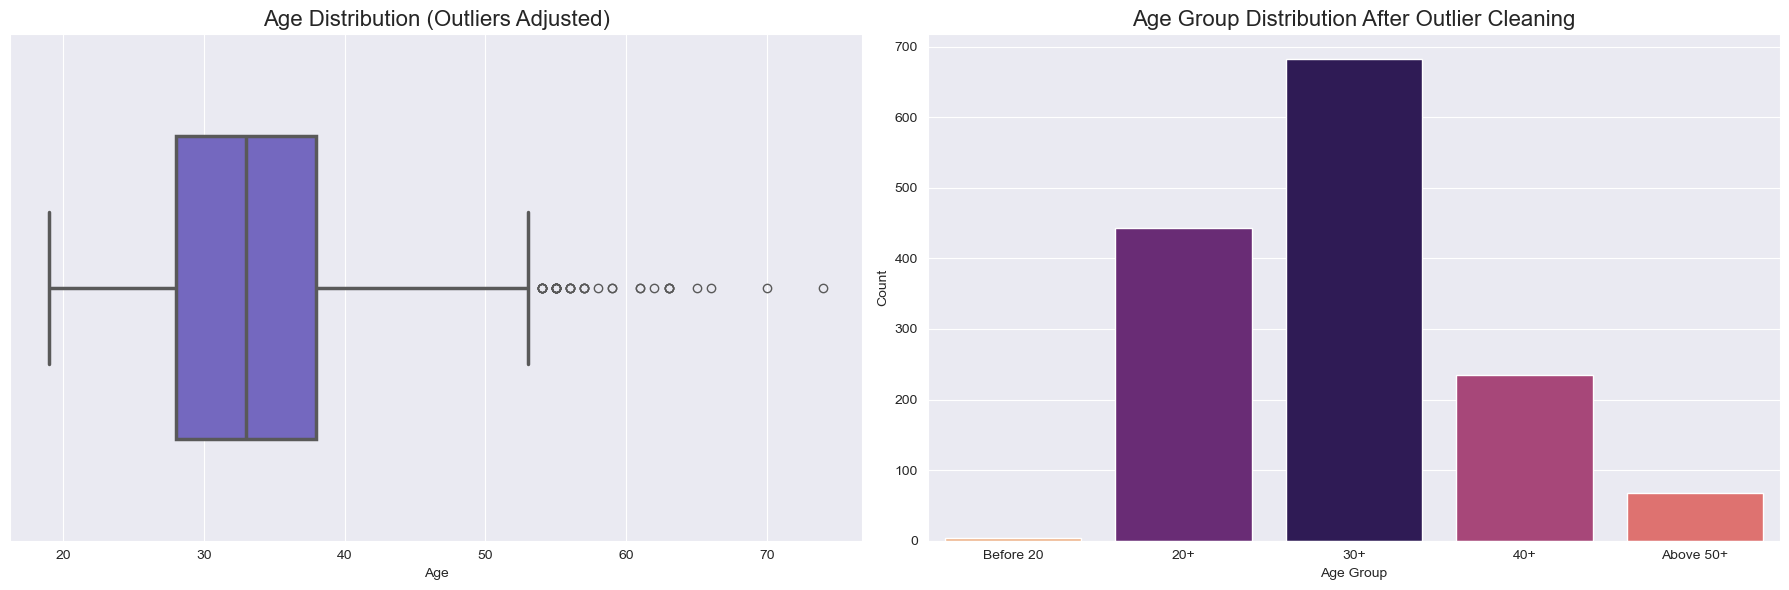

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Ensure 'Age' is numeric
df_processed['Age'] = pd.to_numeric(df_processed['Age'], errors='coerce')

# Step 1: Adjust outliers (<18 or >75) with the mean of valid range
valid_age_mask = (df_processed['Age'] >= 18) & (df_processed['Age'] <= 75)
valid_mean = round(df_processed.loc[valid_age_mask, 'Age'].mean())
df_processed.loc[~valid_age_mask, 'Age'] = valid_mean

# Step 2: Define age group categories
def categorize_age(age):
    if 17 <= age < 20:
        return 'Before 20'
    elif 20 <= age < 30:
        return '20+'
    elif 30 <= age < 40:
        return '30+'
    elif 40 <= age < 50:
        return '40+'
    elif 50 <= age <= 75:
        return 'Above 50+'
    else:
        return 'Other'

df_processed['Age Group'] = df_processed['Age'].apply(categorize_age)

# Step 3: Create subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
sns.set_style("whitegrid")

# Left Plot: Boxplot of adjusted age
sns.boxplot(data=df_processed['Age'], color='slateblue', orient='h', linewidth=2.5, width=0.6, ax=ax1)
ax1.set_title('Age Distribution (Outliers Adjusted)', fontsize=16)

# Right Plot: Age group distribution
sns.countplot(
    data=df_processed,
    x='Age Group',
    order=['Before 20', '20+', '30+', '40+', 'Above 50+'],
    hue='Age Group',
    palette='magma',
    legend=False,
    ax=ax2
)
ax2.set_title("Age Group Distribution After Outlier Cleaning", fontsize=16)
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Count")

plt.tight_layout()

# Save the combined plot
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, "age_combined.png")
plt.savefig(plot_path)

plt.show()


In [15]:
#df_processed.drop(columns=['Age'], inplace=True)
#df_processed.rename(columns={'Age Group': 'Age'}, inplace=True)

## Gender

In [16]:
len(df.Gender.value_counts())
df[['Gender']].head(20)

,Gender
0,Male
1,male
2,Male
3,male
4,Female
5,Male
6,M
7,female
8,Female
9,Male


In [17]:

# Define gender category lists
Male = ['Male', 'male', 'Male ', 'M', 'm','man', 'Cis male', 'Male.', 'male 9:1 female, roughly', 'Male (cis)',
        'Man', 'Sex is male','cis male', 'Malr', 'Dude',
        "I'm a man why didn't you make this a drop down question. You should of asked sex? And I would of answered yes please. Seriously how much text can this take? ",
        'mail', 'M|', 'Male/genderqueer', 'male ', 'Cis Male', 'Male (trans, FtM)', 'cisdude', 'cis man', 'MALE']

Female = ['Female', 'female', 'I identify as female.', 'female ','Female assigned at birth ', 'F', 'Woman',
          'fm', 'f', 'Cis female ', 'Transitioned, M2F', 'Genderfluid (born female)',
          'Female or Multi-Gender Femme', 'Female ', 'woman', 'female/woman','Cisgender Female', 'fem',
          'Female (props for making this a freeform field, though)',' Female', 'Cis-woman',
          'female-bodied; no feelings about gender','AFAB']

other = ['Bigender', 'non-binary', 'Other/Transfeminine', 'Androgynous', 'Other', 'nb masculine',
         'none of your business', 'genderqueer', 'Human', 'Genderfluid','Enby', 'genderqueer woman', 'mtf',
         'Queer', 'Agender', 'Fluid','Nonbinary', 'human', 'Unicorn', 'Genderqueer','Genderflux demi-girl',
         'Transgender woman','Yes','No']

# Replace all values in the Gender column
df_processed['Gender'] = df_processed['Gender'].replace(to_replace=Male, value='Male')
df_processed['Gender'] = df_processed['Gender'].replace(to_replace=Female, value='Female')
df_processed['Gender'] = df_processed['Gender'].replace(to_replace=other, value='Other')

# Print result
print(df_processed['Gender'].value_counts())

Gender
Male      1063
Female     343
Other       27
Name: count, dtype: int64


In [18]:
# Now safe to modify
df_processed['Gender'] = df_processed['Gender'].str.strip().str.lower()
df_processed = df_processed[df_processed['Gender'] != 'other'].copy()  # Filter and copy again
df_processed['Gender'] = df_processed['Gender'].replace({'male': 'Male', 'female': 'Female'})

# Check results
print(df_processed['Gender'].value_counts())

Gender
Male      1063
Female     343
Name: count, dtype: int64


## Country

In [19]:
print(df_processed['Working Country'].value_counts())
print(df_processed['Living Country'].value_counts())

Working Country
United States of America    835
United Kingdom              178
Canada                       73
Germany                      56
Netherlands                  46
Australia                    34
Sweden                       20
Ireland                      14
France                       14
Brazil                       10
Switzerland                   9
India                         9
Russia                        9
New Zealand                   9
Denmark                       7
Bulgaria                      7
Finland                       7
Belgium                       5
South Africa                  4
Poland                        4
Austria                       4
Czech Republic                3
Italy                         3
Chile                         3
Norway                        3
Romania                       3
Spain                         3
Other                         2
Bosnia and Herzegovina        2
Afghanistan                   2
Pakistan                

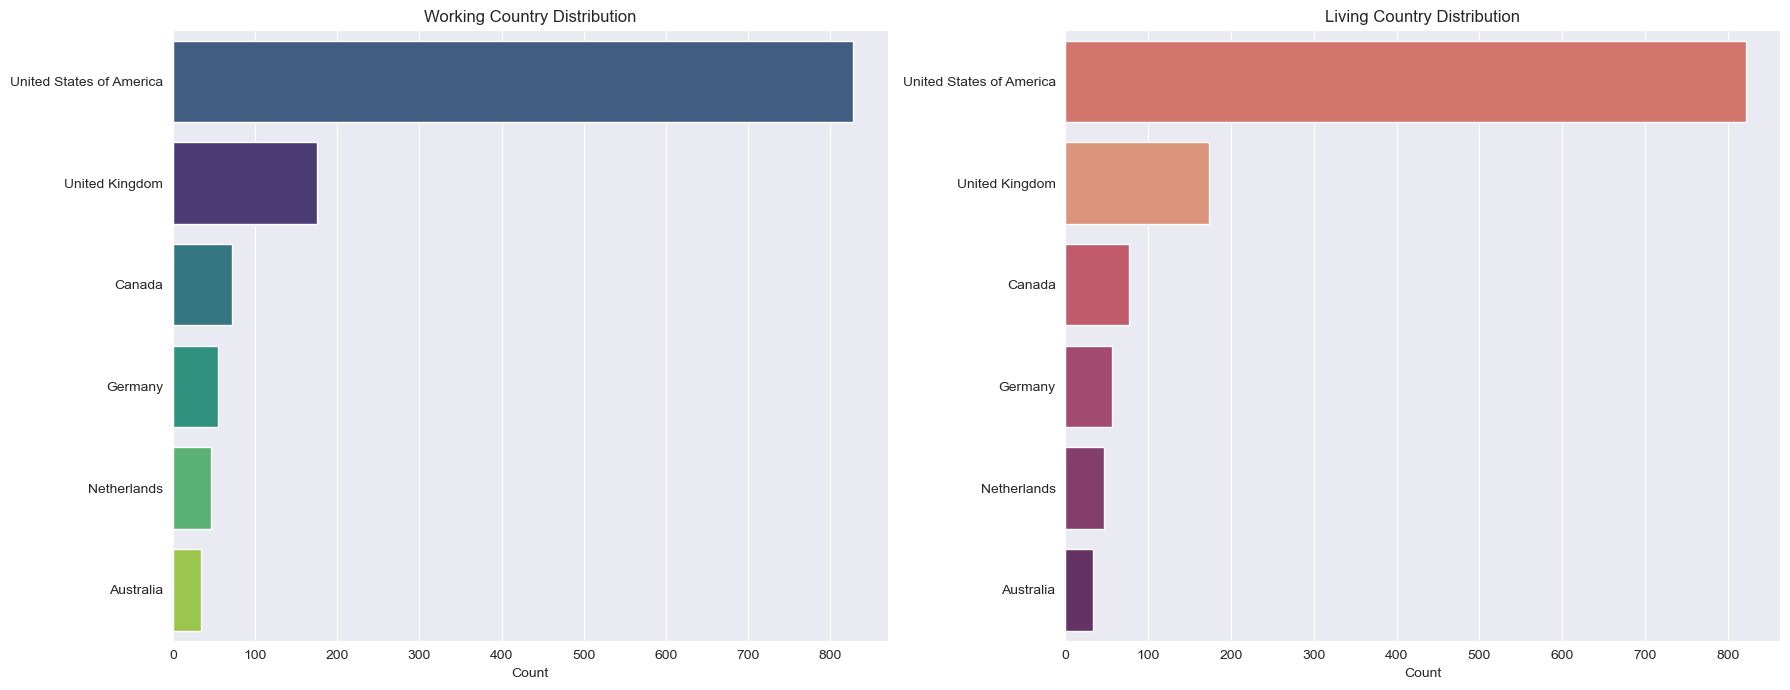

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the list of target countries
target_countries = ["United States of America", "United Kingdom", "Canada", "Germany", "Netherlands", "Australia"]

# Filter the DataFrame
df_processed = df_processed[
    df_processed['Working Country'].isin(target_countries) &
    df_processed['Living Country'].isin(target_countries)
]

# Set style for plots
sns.set_style("darkgrid")

# Set up a side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=False)

# Plot 1 - Working Country
sns.countplot(
    data=df_processed,
    y='Working Country',
    order=df_processed['Working Country'].value_counts().index,
    palette='viridis',
    ax=axes[0],
    hue='Working Country',
    legend=False
)
axes[0].set_title("Working Country Distribution")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

# Plot 2 - Living Country
sns.countplot(
    data=df_processed,
    y='Living Country',
    order=df_processed['Living Country'].value_counts().index,
    palette='flare',
    ax=axes[1],
    hue='Living Country',
    legend=False
)
axes[1].set_title("Living Country Distribution")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")


# Layout adjustment
plt.tight_layout()

# Save plot to 'images' directory
import os
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, "working_living_country_distribution.png")
plt.savefig(plot_path)

# Show the plot
plt.show()

In [21]:
country_rename_map = {
    "United States of America": "US",
    "United Kingdom": "UK",
    "Germany": "DE",
    "Canada": "CA",
    "Netherlands": "NL",
    "Australia": "AU"
}
df_processed['Working Country'] = df_processed['Working Country'].replace(country_rename_map)
df_processed['Living Country'] = df_processed['Living Country'].replace(country_rename_map)
# Filter the countries that have at least 20 entries in both 'Working Country' and 'Living Country'
df_processed = df_processed[df_processed['Working Country'].map(df_processed['Working Country'].value_counts()) >= 20]
df_processed = df_processed[df_processed['Living Country'].map(df_processed['Living Country'].value_counts()) >= 20]

To streamline the dataset and ensure clarity, we renamed the column Country to country_code, reflecting its role as a categorical identifier. Simultaneously, we retained only the countries with more than 20 entries in the dataset to focus the analysis on segments with sufficient representation, thereby improving the reliability of insights.

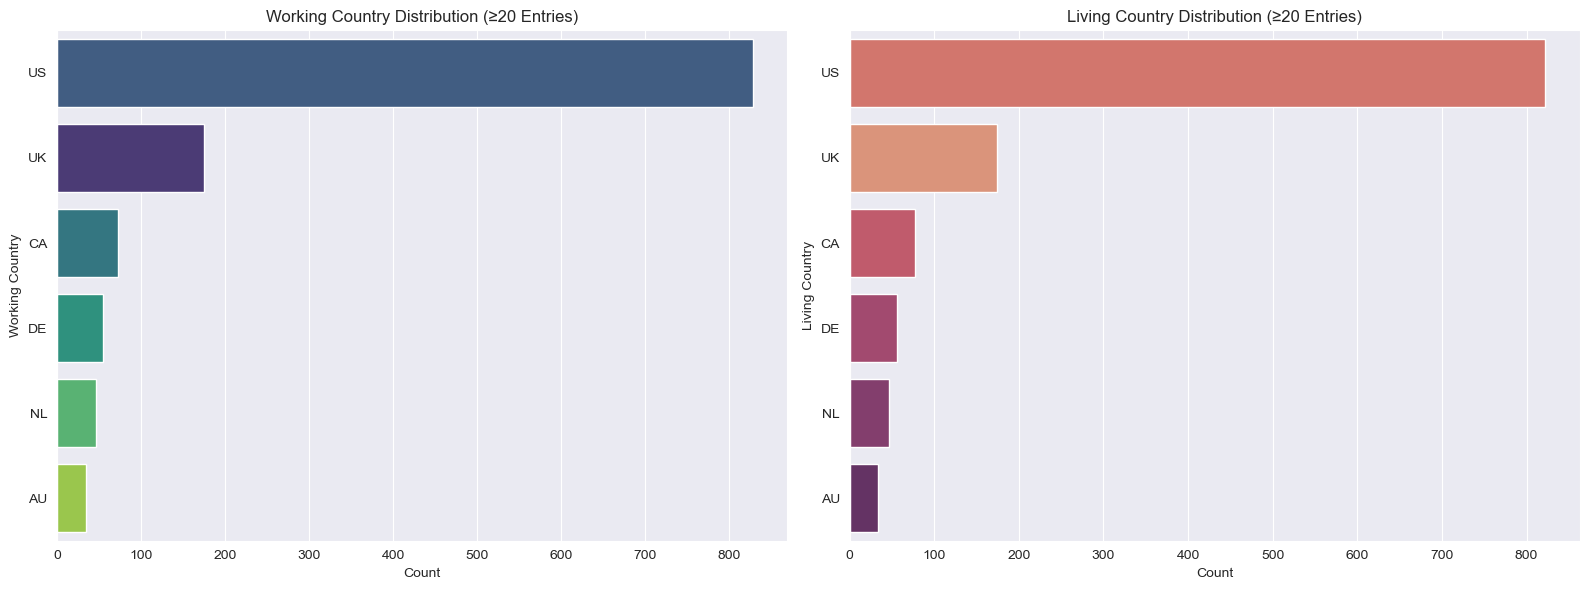

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set_style("darkgrid")

# Create a figure with 2 subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

# --- Plot Working Country ---
sns.countplot(data=df_processed, y='Working Country',
              hue='Working Country',  # Add hue to silence the warning
              dodge=False,            # Prevent splitting bars
              order=df_processed['Working Country'].value_counts().index,
              palette='viridis', ax=ax[0], legend=False)
ax[0].set_title("Working Country Distribution (≥20 Entries)")
ax[0].set_xlabel("Count")
ax[0].set_ylabel("Working Country")

# --- Plot Living Country ---
sns.countplot(data=df_processed, y='Living Country',
              hue='Living Country',
              dodge=False,
              order=df_processed['Living Country'].value_counts().index,
              palette='flare', ax=ax[1], legend=False)
ax[1].set_title("Living Country Distribution (≥20 Entries)")
ax[1].set_xlabel("Count")
ax[1].set_ylabel("Living Country")

# Adjust layout
plt.tight_layout()

# Save plot to img directory
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, "renamed_working_living_country_distribution.png")
plt.savefig(plot_path)
# show the plot
plt.show()

Why / Why not

In [23]:
negative_impact_conditions = ["depend", "support", "same", "bad", "deter", "relate", "qualif",
                              "underst", "hurt", 'chance', "crazy", "doubt",  "weak", "product", "liability",
                              "nothing", "allude", "reject", "respect", "eliminat", "pass", "leave", "filter", "expect",
                              "complain"]

discrimination_conditions = ["stigma", "discrimination", "cost", "serious", "IQ", "believe", "disqualify", "discount", "prejudice",
                             "taboo", "judge", "fear", "disability", "unstable", "unreliable"]

privacy_conditions = ["personal", "priva", "accommodation", "situation", "trust", "problem", "shar", "sensitive", "never",
                      "feel", "business", "reflect", "embarass", "obligat", "concern", "condition"]

uncertainty_conditions = ["reaction", "recept", "sure", "issue", "offer", "know", "neg", "afraid", "refus",
                          "necessary", "vulnerable", "stupid", "crap"]

job_performance_conditions = ["map", "bias", "impact", "compromise", "uncomfortable", "relate", "job", "against",
                              "sign", "discuss", "ffect", "no"]

legal_conditions = ["manageable", "suicide", "dismis", "depression", "anxiety", "ocd", "burn", "consider"]

transparency_conditions = ["support", "relevant", "reaction", "prompt", "doubt", "perceive", "risk", "accept", "honest",
                          "perception", "option", "important", "open", "protect"]

lack_of_benefit_conditions = ["appl", "above", "part", "topical", "stance", "aware","roadblock", "won't", "harm",
                              "position", "benef", "previous", "physical", "potential", "as", "see", "disclos"]

categories = {
    "Negative Impact on Hiring Chances": negative_impact_conditions,
    "Fear of Discrimination or Prejudice": discrimination_conditions,
    "Privacy and Personal Concerns": privacy_conditions,
    "Uncertainty about Employer Reaction": uncertainty_conditions,
    "Concerns about Job Performance or Suitability": job_performance_conditions,
    "Legal and Rights Considerations": legal_conditions,
    "Desire for Transparency and Alignment": transparency_conditions,
    "Lack of Benefit in Disclosing": lack_of_benefit_conditions
}

answer = df_processed['Why/ Why Not_ph']
# Function to categorize each response
def categorize_reason(text):
    text = str(text).lower()
    for category, keywords in categories.items():
        if any(keyword in text for keyword in keywords):
            return category
    return "Other"

# Apply the categorization function
df_processed['Why/ Why Not_ph'] = df_processed['Why/ Why Not_ph'].apply(categorize_reason)

# View the unique categories
print(df_processed['Why/ Why Not_ph'].unique())

['Fear of Discrimination or Prejudice' 'Negative Impact on Hiring Chances'
 'Uncertainty about Employer Reaction'
 'Concerns about Job Performance or Suitability'
 'Privacy and Personal Concerns' 'Other'
 'Desire for Transparency and Alignment' 'Lack of Benefit in Disclosing'
 'Legal and Rights Considerations']


In [24]:
answer = df_processed['Why/Why Not_mh']
# Function to categorize each response
def categorize_reason(text):
    text = str(text).lower()
    for category, keywords in categories.items():
        if any(keyword in text for keyword in keywords):
            return category
    return "Other"

# Apply the categorization function
df_processed['Why/Why Not_mh'] = df_processed['Why/Why Not_mh'].apply(categorize_reason)

# View the unique categories
print(df_processed['Why/Why Not_mh'].unique())

['Fear of Discrimination or Prejudice'
 'Uncertainty about Employer Reaction' 'Negative Impact on Hiring Chances'
 'Privacy and Personal Concerns' 'Desire for Transparency and Alignment'
 'Other' 'Concerns about Job Performance or Suitability'
 'Lack of Benefit in Disclosing' 'Legal and Rights Considerations']


## Company Flag
 For better understanding of company segmentation, we created a new flag indicating whether the respondent works in a company or is self-employed.

In [25]:
# Create a mask for all work positions that contain a tech-related role
mask_tech_company_flag = df_processed['Work Position'].str.contains('Back-end|Front-end|DevOps|SysAdmin|Developer', na=False)

# Initialize the 'tech_role_flag' column as 'No' for all rows
df_processed['tech company Flag'] = 'No'

# Fill 'tech_role_flag' with 'Yes' where the mask is True
df_processed.loc[mask_tech_company_flag , 'tech company Flag'] = 'Yes'

# Show the distribution of tech roles
print(df_processed['tech company Flag'].value_counts())

tech company Flag
Yes    843
No     367
Name: count, dtype: int64


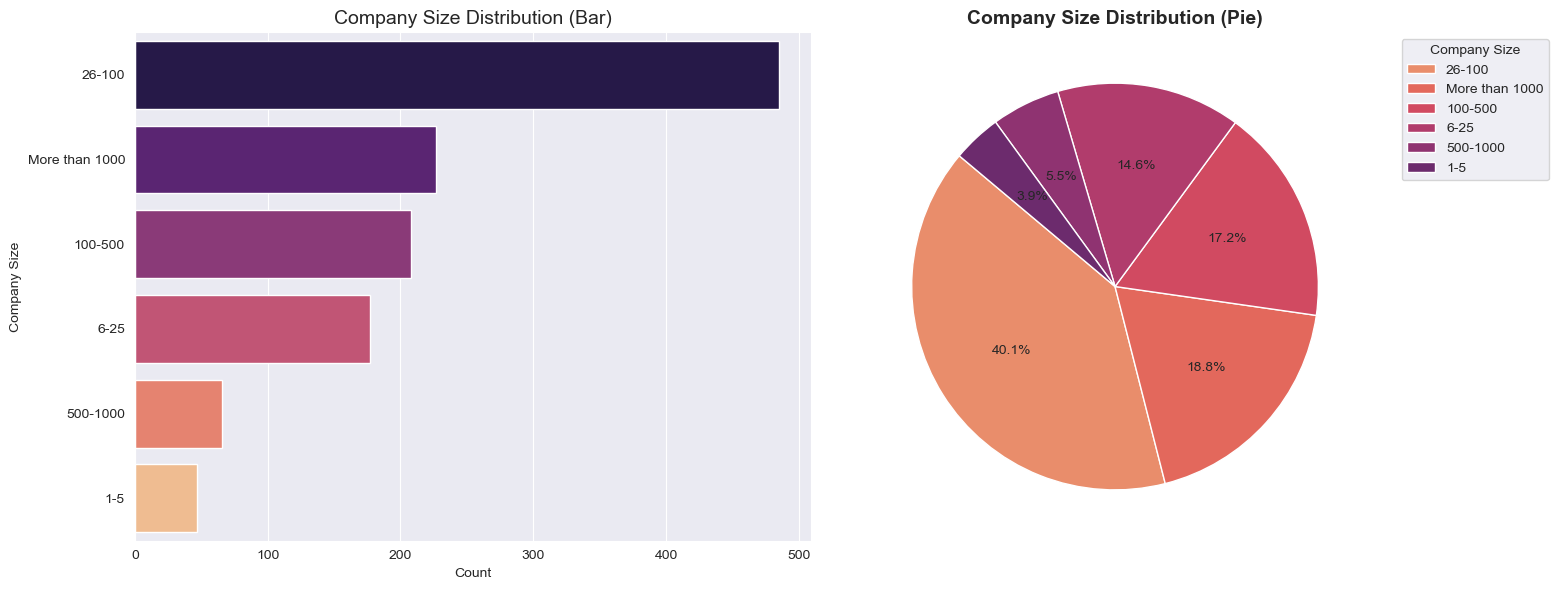

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
company_counts = df_processed['Company Size'].value_counts().reset_index()
company_counts.columns = ['Company Size', 'count']

company_size_counts = df_processed['Company Size'].value_counts().dropna()
company_size_counts = company_size_counts[~company_size_counts.index.str.contains('Not sure', case=False)]

# Percentage formatting for pie chart
def format_pct(pct):
    return f'{pct:.1f}%' if pct > 1 else ''

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.set_style("darkgrid")

# Barplot on ax1
sns.barplot(
    data=company_counts,
    x='count',
    y='Company Size',
    hue='Company Size',
    palette='magma',
    dodge=False,
    legend=False,
    ax=ax1
)
ax1.set_title('Company Size Distribution (Bar)', fontsize=14)
ax1.set_xlabel('Count')
ax1.set_ylabel('Company Size')

# Pie chart on ax2
company_size_counts.plot.pie(
    autopct=format_pct,
    startangle=140,
    colors=sns.color_palette("flare", len(company_size_counts)),
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    labeldistance=None,
    textprops={'fontsize': 10},
    ax=ax2
)
ax2.set_title('Company Size Distribution (Pie)', fontsize=14, fontweight='bold')
ax2.set_ylabel('')  # Hide y-label
ax2.legend(company_size_counts.index, title="Company Size", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Save plot to img directory
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, "company_size_dist.png")
plt.savefig(plot_path)
#show the plot
plt.show()

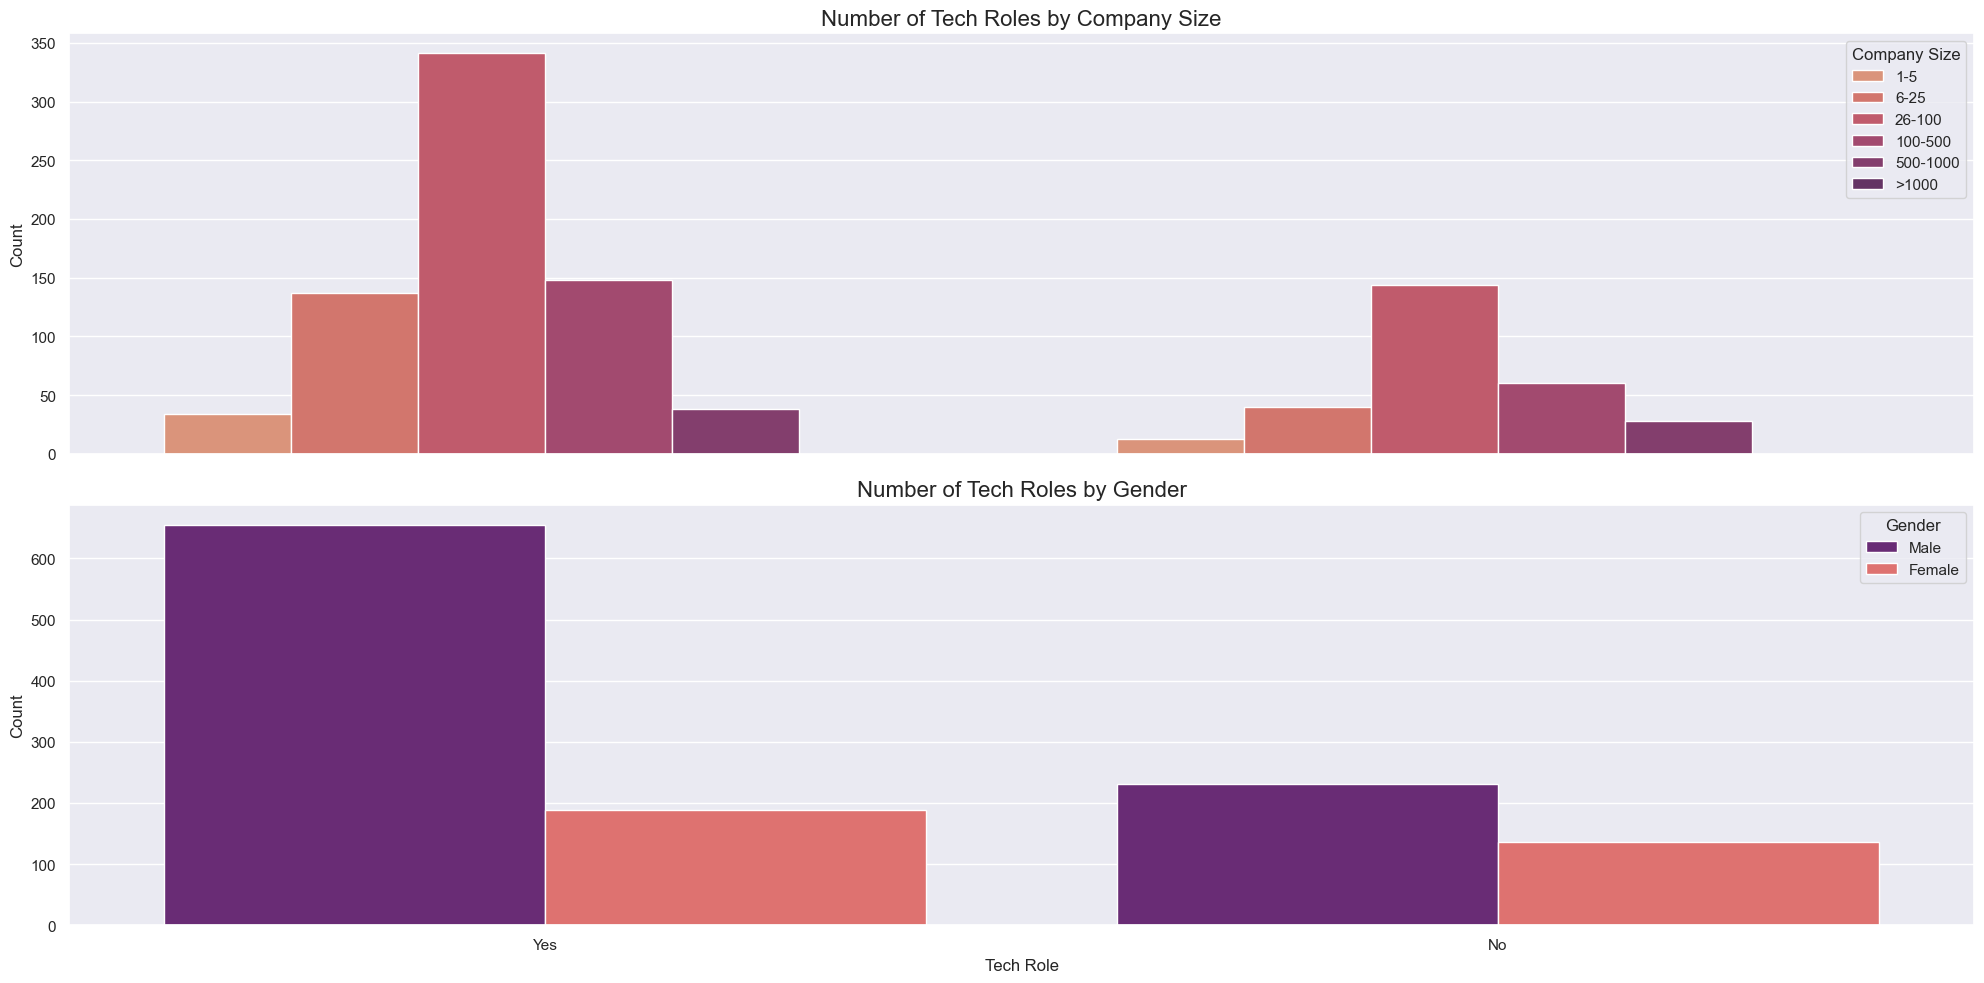

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="darkgrid")

# Create subplots
fig, axes = plt.subplots(nrows=2, figsize=(20, 10), sharex=True)

# Define consistent order for company size
company_order = ["1-5", "6-25", "26-100", "100-500", "500-1000", ">1000"]

# Plot 1: Tech roles by company size
sns.countplot(
    data=df_processed,
    x="tech company Flag",
    hue="Company Size",
    hue_order=company_order,
    palette="flare",
    ax=axes[0]
)
axes[0].set_title("Number of Tech Roles by Company Size", fontsize=16)
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Tech Role")

# Plot 2: Tech roles by gender
sns.countplot(
    data=df_processed,
    x="tech company Flag",
    hue="Gender",
    palette="magma",
    ax=axes[1]
)
axes[1].set_title("Number of Tech Roles by Gender", fontsize=16)
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Tech Role")

# Adjust layout
plt.tight_layout()
# Save plot to 'images' directory
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, "N_Tech_Roles_company_size.png")
plt.savefig(plot_path)
#show the plot
plt.show()

In [28]:

df_processed.head()

,Self Employed,Company Size,tech company Flag,MH Coverage,MH Coverage Awareness,MH Employer Discussion,MH Resources Provided,MH Anonymity,Medical Leave,MH Discussion Neg Impact,...,MH Sought Professional Treatment,MH Effective Treatment Impact,MH NOT Effective Treatment Impact,Age,Gender,Living Country,Working Country,Work Position,Remote Work,Age Group
0,0,26-100,Yes,Not eligible for coverage / N/A,No,No,No,I don't know,Very easy,No,...,0,Not applicable to me,Not applicable to me,39,Male,UK,UK,Back-end Developer,Sometimes,30+
1,0,6-25,Yes,No,Yes,Yes,Yes,Yes,Somewhat easy,No,...,1,Rarely,Sometimes,29,Male,US,US,Back-end Developer|Front-end Developer,Never,20+
2,0,6-25,Yes,No,No,No,No,I don't know,Neither easy nor difficult,Maybe,...,1,Not applicable to me,Not applicable to me,38,Male,UK,UK,Back-end Developer,Always,30+
3,1,26-100,No,Yes,No,No,No,I don't know,Somewhat easy,Maybe,...,1,Sometimes,Sometimes,43,Male,UK,UK,Supervisor/Team Lead,Sometimes,40+
4,0,6-25,Yes,Yes,Yes,No,No,No,Neither easy nor difficult,Yes,...,1,Sometimes,Sometimes,43,Female,US,US,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes,40+


In [29]:
# Suppose df is your original DataFrame
#df_processed.copy()  # After cleaning, before encoding
#df_processed.to_csv('processed_data/cleaned_data.csv', index=False)

## Encoding
Encode categorical variables to convert them into numerical format, which is required for most machine learning algorithms.
 This step ensures consistent representation of categories and enables further processing.

In [30]:
print(df_processed.shape)
df_processed.head()

(1210, 49)


,Self Employed,Company Size,tech company Flag,MH Coverage,MH Coverage Awareness,MH Employer Discussion,MH Resources Provided,MH Anonymity,Medical Leave,MH Discussion Neg Impact,...,MH Sought Professional Treatment,MH Effective Treatment Impact,MH NOT Effective Treatment Impact,Age,Gender,Living Country,Working Country,Work Position,Remote Work,Age Group
0,0,26-100,Yes,Not eligible for coverage / N/A,No,No,No,I don't know,Very easy,No,...,0,Not applicable to me,Not applicable to me,39,Male,UK,UK,Back-end Developer,Sometimes,30+
1,0,6-25,Yes,No,Yes,Yes,Yes,Yes,Somewhat easy,No,...,1,Rarely,Sometimes,29,Male,US,US,Back-end Developer|Front-end Developer,Never,20+
2,0,6-25,Yes,No,No,No,No,I don't know,Neither easy nor difficult,Maybe,...,1,Not applicable to me,Not applicable to me,38,Male,UK,UK,Back-end Developer,Always,30+
3,1,26-100,No,Yes,No,No,No,I don't know,Somewhat easy,Maybe,...,1,Sometimes,Sometimes,43,Male,UK,UK,Supervisor/Team Lead,Sometimes,40+
4,0,6-25,Yes,Yes,Yes,No,No,No,Neither easy nor difficult,Yes,...,1,Sometimes,Sometimes,43,Female,US,US,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes,40+


In [31]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

categorical_renamed = [column for column in df_processed.columns if df_processed[column].dtype == 'object']

ohe = OneHotEncoder(sparse_output=False)  # drop='first' avoids multicollinearity

ohe = pd.DataFrame(ohe.fit_transform(df_processed[categorical_renamed]),
                            columns=ohe.get_feature_names_out(categorical_renamed))

# Drop original categorical columns and concatenate OHE features
#df_processed= pd.concat([df_processed.drop(columns=categorical_renamed), ohe], axis=1)


In [32]:
print(df_processed.columns)

Index(['Self Employed', 'Company Size', 'tech company Flag', 'MH Coverage',
       'MH Coverage Awareness', 'MH Employer Discussion',
       'MH Resources Provided', 'MH Anonymity', 'Medical Leave',
       'MH Discussion Neg Impact', 'PH Discussion Neg Impact',
       'MH Discussion Coworkers', 'MH Discussion Supervisor(s)',
       'MH vs PH Employer', 'MH Consequence Coworkers', 'Previous Employers',
       'Previous MH Benefits', 'Previous MH Awareness',
       'Previous MH Discussion', 'Previous MH Resources Provided',
       'Previous MH Anonymity', 'Previous MH Discussion Neg Impact',
       'Previous PH Discussion Neg Impact', 'Previous MH Discussion Coworkers',
       'Previous MH Discussion Supervisor(s)', 'Previous MH vs PH',
       'Previous MH Coworkers Reveal Neg', 'PH In Interview',
       'Why/ Why Not_ph', 'MH In Interview', 'Why/Why Not_mh',
       'MH Bad Impact on Career', 'MH Neg View of team members/Coworkers',
       'MH Sharing with Family/Friends', 'MH Bad Respon

In [33]:
#encoded_df.to_csv('processed_data/cleaned_data.csv', index=False)
from sklearn.preprocessing import LabelEncoder
#encoded_df = encoded_df.copy()

le = LabelEncoder()

for column in df_processed.columns:
    if df_processed[column].dtype == 'object':
        df_processed[column] = le.fit_transform(df_processed[column].astype(str))



df_processed.head()

,Self Employed,Company Size,tech company Flag,MH Coverage,MH Coverage Awareness,MH Employer Discussion,MH Resources Provided,MH Anonymity,Medical Leave,MH Discussion Neg Impact,...,MH Sought Professional Treatment,MH Effective Treatment Impact,MH NOT Effective Treatment Impact,Age,Gender,Living Country,Working Country,Work Position,Remote Work,Age Group
0,0,2,1,2,1,1,1,0,5,1,...,0,1,1,39,1,4,4,0,2,1
1,0,4,1,1,2,2,2,2,3,1,...,1,3,4,29,1,5,5,8,1,0
2,0,4,1,1,1,1,1,0,1,0,...,1,1,1,38,1,4,4,0,0,1
3,1,2,0,3,1,1,1,0,3,0,...,1,4,4,43,1,4,4,174,2,2
4,0,4,1,3,2,1,1,1,1,2,...,1,4,4,43,0,5,5,74,2,2


## Correlation matrix

Compute the correlation matrix to identify relationships between numerical variables. This helps in understanding potential multicollinearity and guides decisions in feature selection or dimensionality reduction.trong correlations (positive or negative) may indicate redundancy or patterns worth exploring further.


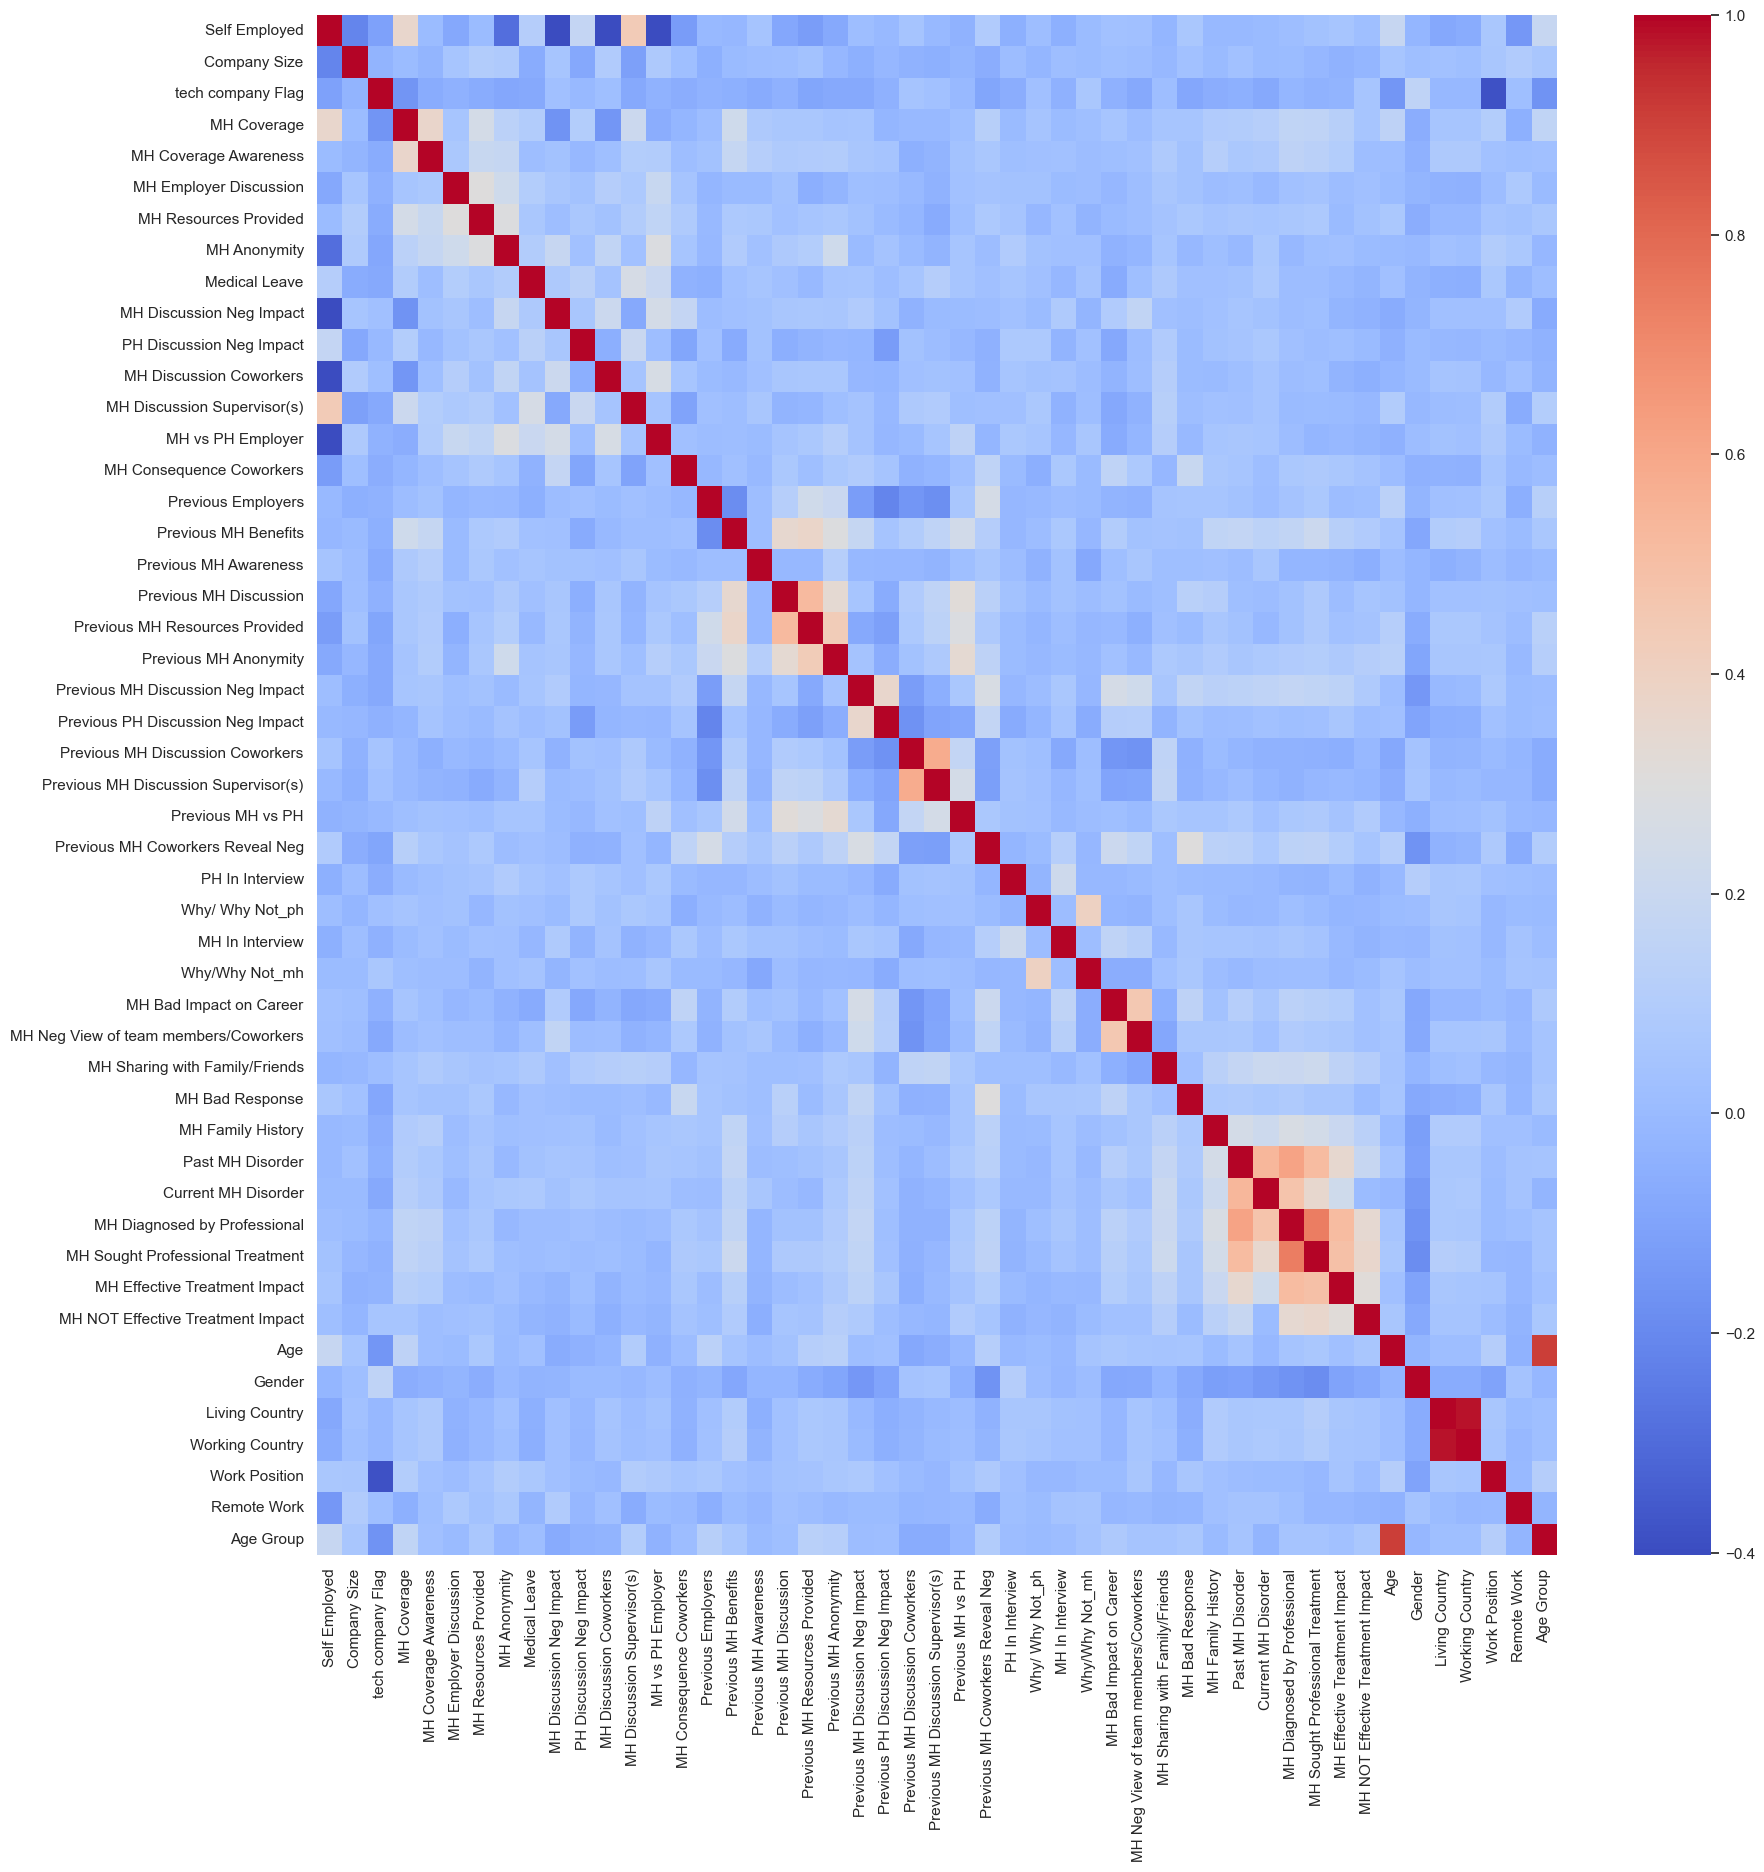

In [34]:
correlation_matrix = df_processed.corr()

plt.figure(figsize=(20, 20))

# Heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', cbar=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [35]:
columns_to_drop = df_processed.filter(regex='Working Country').columns.to_list() # dropping country_work columns
df_processed.drop(columns=columns_to_drop, inplace=True)
df_processed.shape

(1210, 48)

## Cumulative Variance
Apply PCA to determine the number of components needed to retain most of the dataset's variance. The cumulative explained variance plot helps identify the optimal number of dimensions to keep those explaining 80% of the variance, supporting dimensionality reduction while preserving key information.


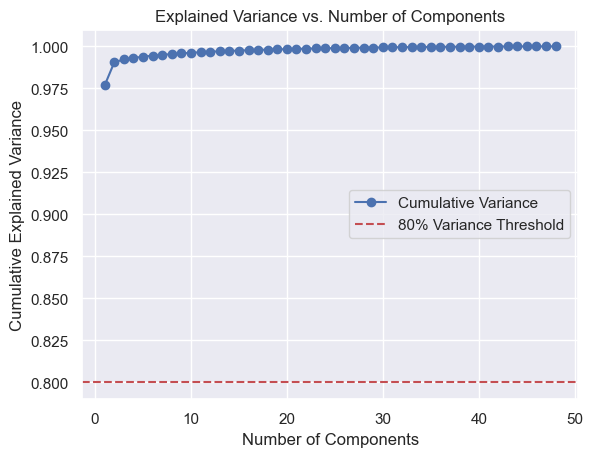

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=None)
pca.fit(df_processed)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', label='Cumulative Variance')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Variance Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.legend()
plt.show()


 ## Dimensionality Reduction

Applying PCA fo dmension reduction

In [37]:
pca = PCA(n_components=48, random_state=1)  # Retain 90% of the variance and choose 60 most important features
data_pca = pca.fit_transform(df_processed)

pca_columns = [f'PC{i+1}' for i in range(data_pca.shape[1])]
df_pca = pd.DataFrame(data_pca, columns=pca_columns)

# Check explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)

# Step 4: Add PCA columns back to the original dataset
df_transformed = pd.concat([df_processed.reset_index(drop=True), df_pca], axis=1)

Explained Variance Ratio: [9.76742802e-01 1.36738438e-02 1.89606435e-03 8.10955134e-04
 7.14666673e-04 6.25535507e-04 4.91049428e-04 4.56809154e-04
 3.94014281e-04 3.65975161e-04 3.40435503e-04 3.22988323e-04
 2.30786091e-04 2.21957785e-04 2.09764218e-04 1.93917843e-04
 1.89428433e-04 1.70069312e-04 1.52118871e-04 1.40893751e-04
 1.35864732e-04 1.30357867e-04 1.23403700e-04 1.13867312e-04
 1.01330723e-04 9.77453710e-05 9.19045021e-05 8.58725303e-05
 7.80341559e-05 7.31947697e-05 7.15375021e-05 5.96972679e-05
 5.57487433e-05 5.06038363e-05 4.91071820e-05 4.48456682e-05
 3.91519758e-05 3.77295997e-05 3.29616828e-05 3.21260606e-05
 2.97089451e-05 2.86407118e-05 2.66651451e-05 2.18477323e-05
 1.24778684e-05 1.15069032e-05 1.09340453e-05 9.05760070e-06]


apply Elbow , silhouette and Davies-Bouldin metrics


k=2, Silhouette Score=0.6104
k=2, Davies-Bouldin Index=0.5337
k=3, Silhouette Score=0.5720
k=3, Davies-Bouldin Index=0.5517
k=4, Silhouette Score=0.5527
k=4, Davies-Bouldin Index=0.5998
k=5, Silhouette Score=0.5381
k=5, Davies-Bouldin Index=0.6134
k=6, Silhouette Score=0.5156
k=6, Davies-Bouldin Index=0.7025
k=7, Silhouette Score=0.5011
k=7, Davies-Bouldin Index=0.7289
k=8, Silhouette Score=0.4665
k=8, Davies-Bouldin Index=0.8051
k=9, Silhouette Score=0.3878
k=9, Davies-Bouldin Index=0.9799
k=10, Silhouette Score=0.3886
k=10, Davies-Bouldin Index=0.9576


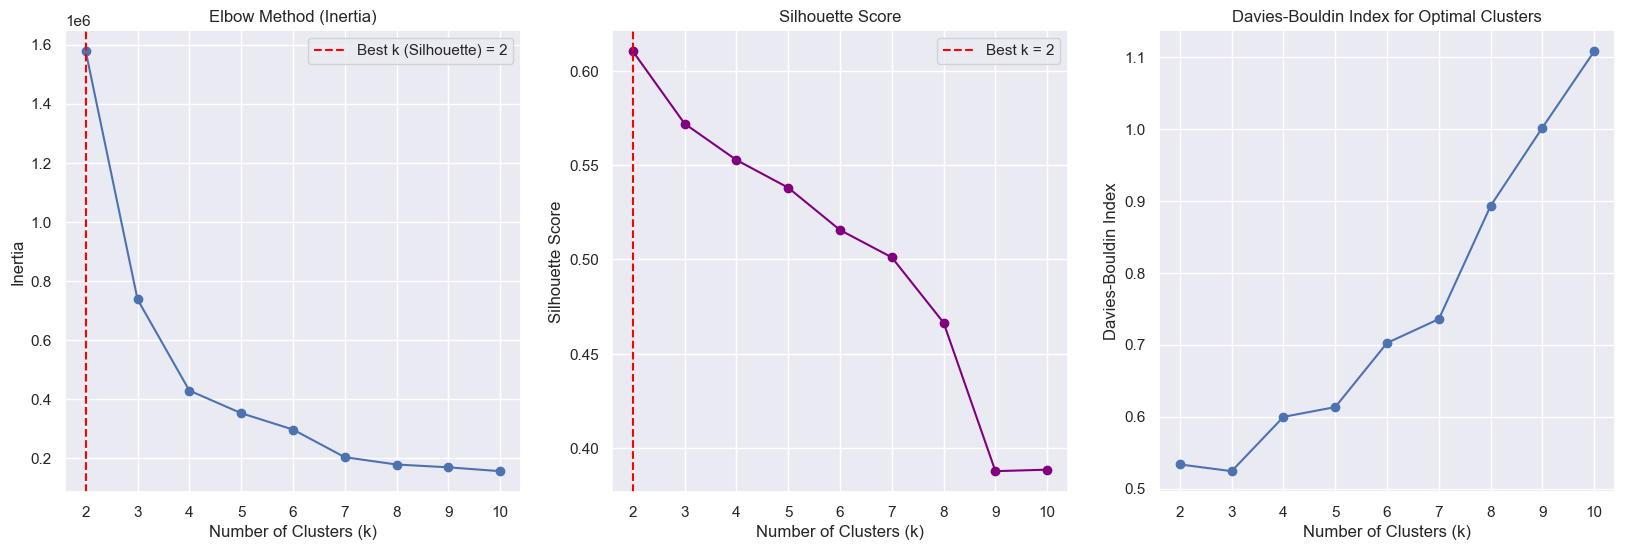

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Define range of k values to test
k_range = range(2, 11)

inertia = []
silhouette_scores = []
db_scores = []

# Loop over k values to compute all metrics
for k in k_range:
    kmeans = KMeans(n_clusters=k, max_iter=500, random_state=1)
    labels = kmeans.fit_predict(data_pca)

    inertia.append(kmeans.inertia_)

    sil_score = silhouette_score(data_pca, labels)
    silhouette_scores.append(sil_score)
    print(f"k={k}, Silhouette Score={sil_score:.4f}")

    db_index = davies_bouldin_score(data_pca, labels)
    db_scores.append(db_index)
    print(f"k={k}, Davies-Bouldin Index={db_index:.4f}")

# Find optimal k based on max silhouette score
optimal_k_sil = k_range[np.argmax(silhouette_scores)]

# Find optimal k based on min Davies-Bouldin index
optimal_k_db = k_range[np.argmin(db_scores)]

# Create output directory if it doesn't exist
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)

# Plot all three metrics side-by-side
plt.figure(figsize=(20, 6))

# Elbow Plot (Inertia)
plt.subplot(1, 3, 1)
plt.plot(k_range, inertia, marker='o')
plt.axvline(x=optimal_k_sil, color='red', linestyle='--', label=f'Best k (Silhouette) = {optimal_k_sil}')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.grid(True)
plt.legend()

# Silhouette Plot
plt.subplot(1, 3, 2)
plt.plot(k_range, silhouette_scores, color='purple', marker='o')
plt.axvline(x=optimal_k_sil, color='red', linestyle='--', label=f'Best k = {optimal_k_sil}')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid(True)
plt.legend()

# Davies-Bouldin Plot (no red line)
plt.subplot(1, 3, 3)
db_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_pca)
    db_scores.append(davies_bouldin_score(data_pca, labels))

# Plot Davies-Bouldin Index
#plt.figure(figsize=(8, 6))
plt.plot(k_range, db_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index for Optimal Clusters')

# Save plot to 'images' directory
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, "renamed_working_living_country_distribution.png")
plt.savefig(plot_path)


plt.show()


## Clustering

Cluster our data using k-means and choose thr otimal k based on result from Davies-Boudin index

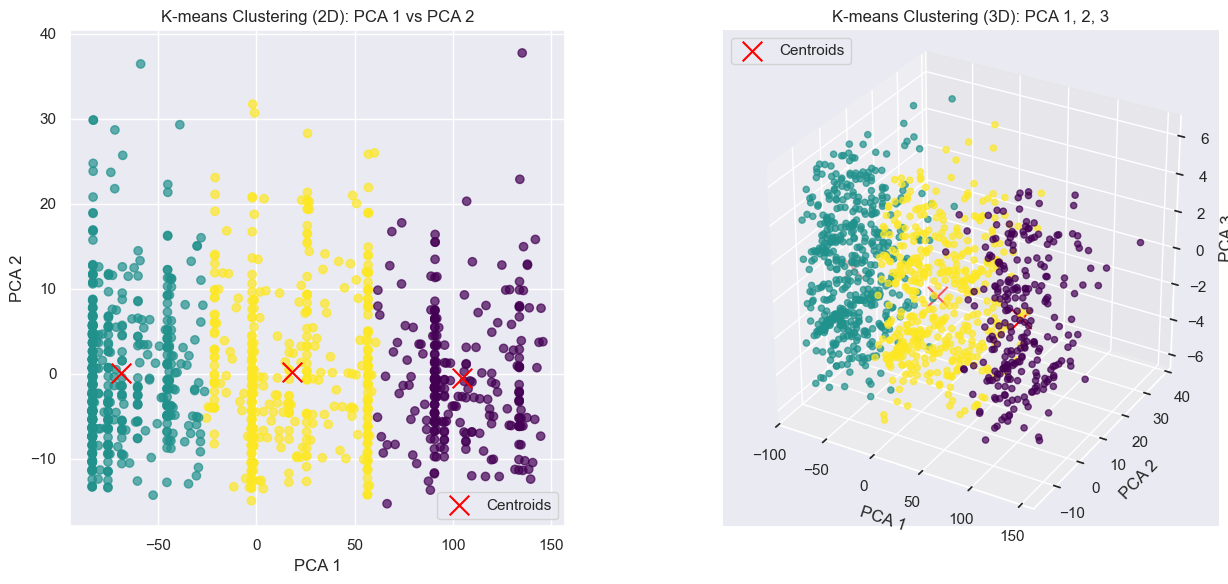

In [39]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.gridspec as gridspec

# Clustering
kmeans = KMeans(n_clusters=3, max_iter=500, random_state=1)
labels = kmeans.fit_predict(data_pca)
centroids = kmeans.cluster_centers_

# Prepare directories
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../images', exist_ok=True)

# DataFrames
df_pca = pd.DataFrame(data_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster'] = labels
df_processed['Cluster'] = labels

# Save cluster summary
cluster_summary = df_processed.groupby('Cluster').mean(numeric_only=True).T
#cluster_summary.to_csv('outputs/cluster_summary.csv')

# Create figure and grid layout
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# ---- 2D Plot ----
ax1 = fig.add_subplot(gs[0])
ax1.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', alpha=0.7)
ax1.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='x', label='Centroids')
ax1.set_title('K-means Clustering (2D): PCA 1 vs PCA 2')
ax1.set_xlabel('PCA 1')
ax1.set_ylabel('PCA 2')
ax1.legend()
ax1.set_box_aspect(1)  # Force square box

# ---- 3D Plot ----
ax2 = fig.add_subplot(gs[1], projection='3d')
ax2.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'],
            c=df_pca['Cluster'], cmap='viridis', alpha=0.7)
ax2.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
            c='red', s=200, marker='x', label='Centroids')
ax2.set_title('K-means Clustering (3D): PCA 1, 2, 3')
ax2.set_xlabel('PCA 1')
ax2.set_ylabel('PCA 2')
ax2.set_zlabel('PCA 3')
ax2.set_box_aspect([1, 1, 1])  # Make cube-like box
ax2.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('images/kmeans_2D_3D_same_size.png', dpi=300)
plt.show()


There are some isolated points, but they don’t affect the general structure of the clusters.which is acceptable.

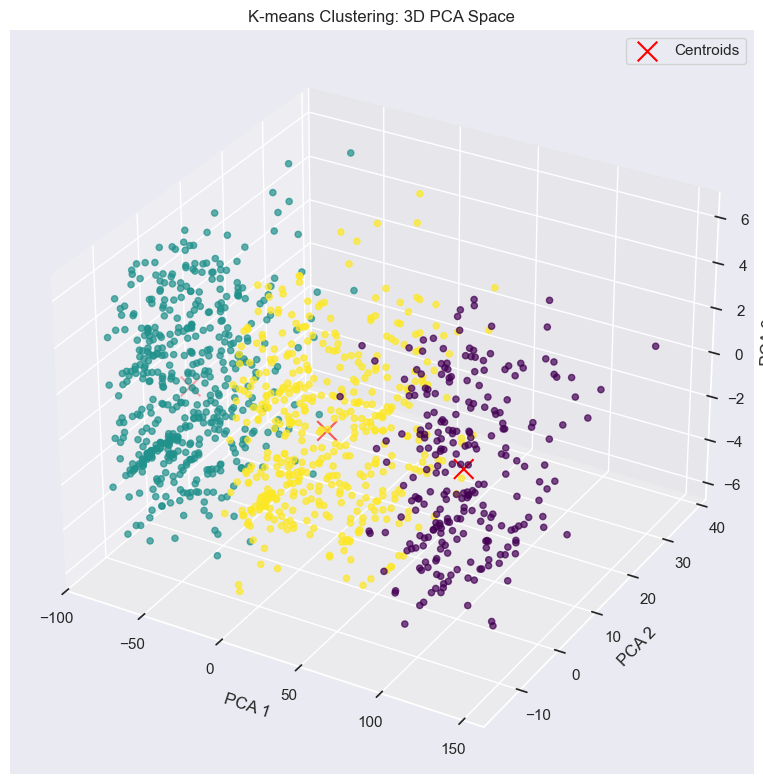

In [40]:
# Assuming data_pca is the PCA-transformed numpy array with at least 3 components
kmeans = KMeans(n_clusters=3, max_iter=500, random_state=1)
label = kmeans.fit_predict(data_pca)

# Create folder if it doesn't exist
os.makedirs('../outputs', exist_ok=True)

# Create DataFrame for PCA results and assign cluster labels
df_pca = pd.DataFrame(data_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster'] = label
df_processed['Cluster'] = label  # df_cluster must match the raw data used for interpretation

# Save summary of cluster characteristics
cluster_summary = df_processed.groupby('Cluster').mean(numeric_only=True).T
#cluster_summary.to_csv('images/cluster_feature_3D.png')


# 3D Plot of Clusters with Centroids
centroids = kmeans.cluster_centers_

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points
scatter = ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'],
                     c=df_pca['Cluster'], cmap='viridis', alpha=0.7)

# Plot the centroids
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
           c='red', s=200, marker='x', label='Centroids')

# Labels and legend
ax.set_title('K-means Clustering: 3D PCA Space')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.legend()

plt.tight_layout()
plt.show()


In [102]:
import joblib

# Save the fitted OneHotEncoder
joblib.dump(ohe, '../encoders/ohe_encoder.joblib')

['../encoders/ohe_encoder.joblib']

In [42]:
kmeans = KMeans(n_clusters=3, max_iter=500, random_state=1)
label = kmeans.fit_predict(data_pca)

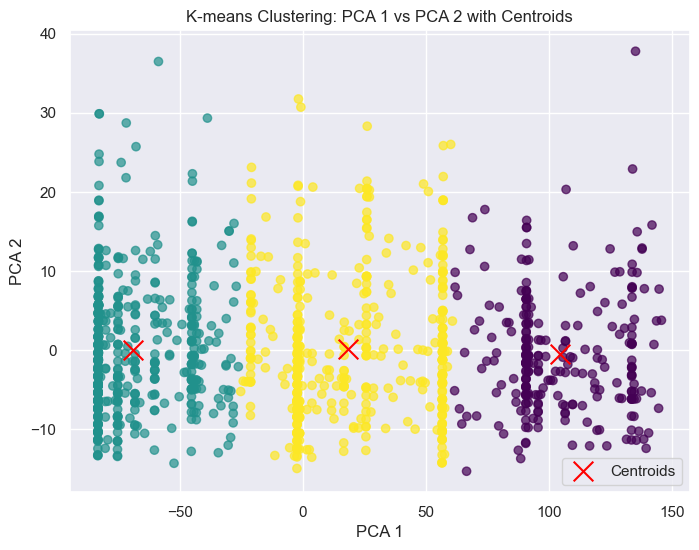

In [43]:
import os
os.makedirs('../outputs', exist_ok=True)  # Create folder if it doesn't exist

centroids = kmeans.cluster_centers_
df_pca['Cluster'] = label
df_processed['Cluster'] = label


# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='x', label='Centroids')
plt.title('K-means Clustering: PCA 1 vs PCA 2 with Centroids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()


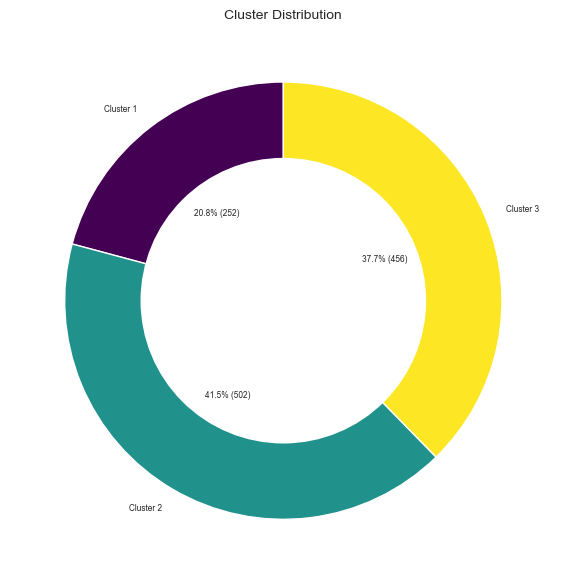

In [44]:
import matplotlib.cm as cm

# Count the number of samples in each cluster
sizes = df_processed['Cluster'].value_counts().sort_index().tolist()
cl_labels = [f'Cluster {i + 1}' for i in range(len(sizes))]

# Function to display percent and count
def func(val):
    a = int(np.round(val / 100. * sum(sizes)))
    return f'{round(val, 1)}% ({a})'

# Colors
colors = cm.viridis(np.linspace(0, 1, len(sizes)))

# Plot
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=cl_labels,
    autopct=func,
    startangle=90,
    pctdistance=0.5,
    colors=colors,
    textprops={'fontsize': 6}
)

# Donut hole
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Adjust label font sizes
for text in texts:
    text.set_fontsize(6)

plt.title("Cluster Distribution", fontsize=10)
plt.tight_layout()

# Save and show
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "cluster_distribution_donut.png"))
plt.show()


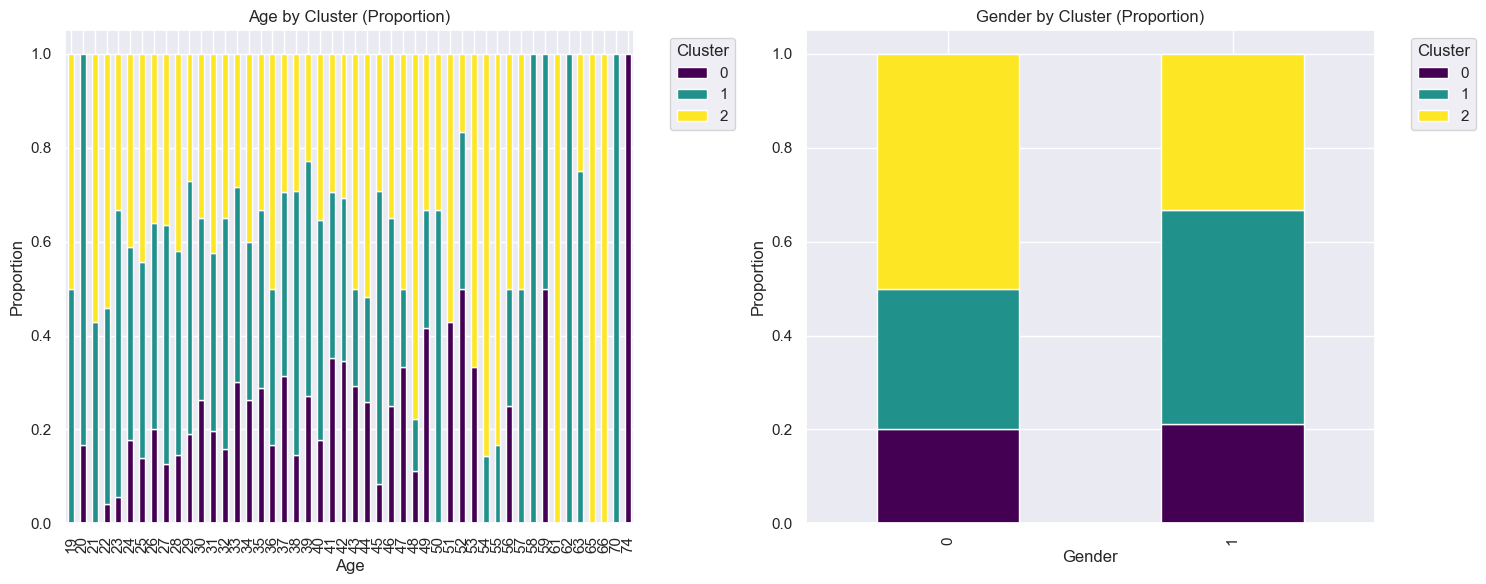

In [45]:

# Normalize counts to show proportions
def plot_cluster_proportions(df, col, ax):
    cluster_counts = pd.crosstab(df[col], df["Cluster"], normalize='index')
    cluster_counts.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
    ax.set_title(f"{col} by Cluster (Proportion)")
    ax.set_ylabel("Proportion")
    ax.set_xlabel(col)
    ax.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

plot_cluster_proportions(df_processed, 'Age', ax[0])
plot_cluster_proportions(df_processed, 'Gender', ax[1])

# Save and show
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "cluster_distribution_Gender_aget.png"))

plt.tight_layout()
plt.show()

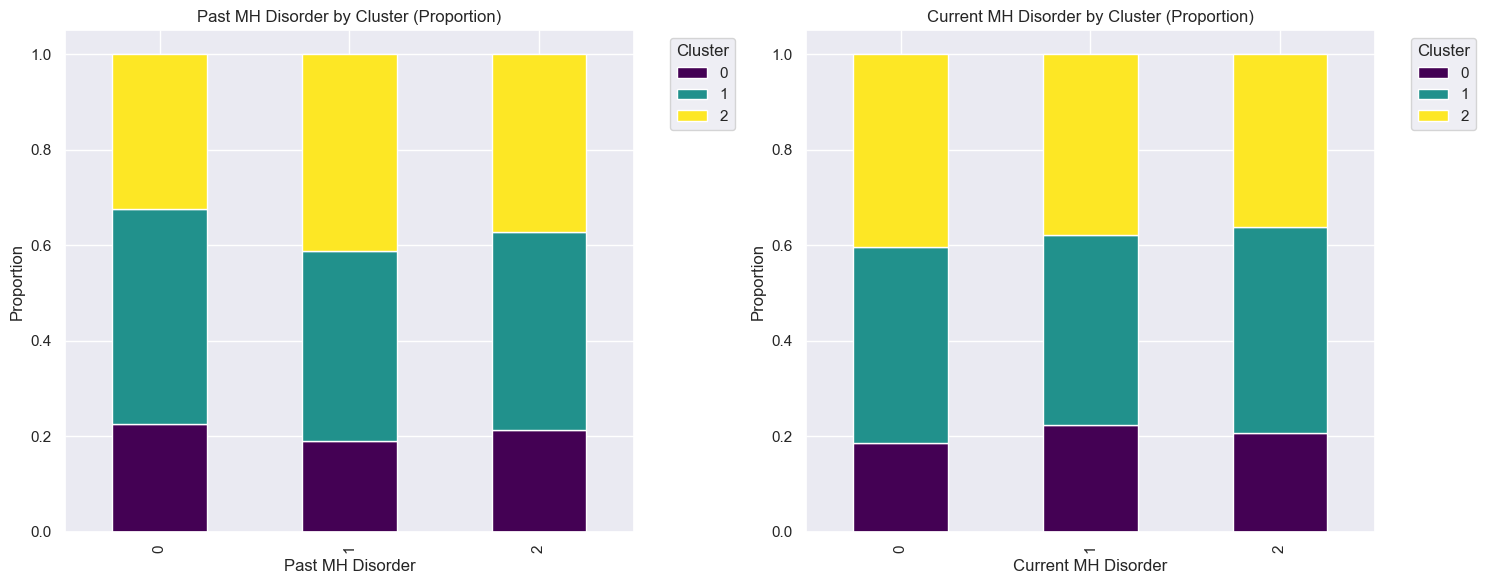

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Function to plot normalized cluster proportions as stacked bars
def plot_cluster_proportions(df, col, ax):
    cluster_counts = pd.crosstab(df[col], df["Cluster"], normalize='index')
    cluster_counts.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')  # You can change colormap if you want
    ax.set_title(f"{col} by Cluster (Proportion)")
    ax.set_ylabel("Proportion")
    ax.set_xlabel(col)
    ax.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# Create subplots for the two mental health questions
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

plot_cluster_proportions(df_processed, 'Past MH Disorder', ax[0])
plot_cluster_proportions(df_processed, 'Current MH Disorder', ax[1])

# Save and show
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "cluster_distribution_MH_disorder.png"))

plt.tight_layout()
plt.show()

In [47]:
col_for_clustering_1 = ['Age', 'Past MH Disorder', 'Current MH Disorder',  'MH Diagnosed by Professional', 'MH Sought Professional Treatment' ]

In [48]:
pca = PCA(n_components=3, random_state=1)  # Retain 85% of the variance and choose 4 most important features
data_pca = pca.fit_transform(df_processed[col_for_clustering_1])

pca_columns = [f'PC{i+1}' for i in range(data_pca.shape[1])]
df_pca = pd.DataFrame(data_pca, columns=pca_columns)

# Check explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance), data_pca.shape


Explained Variance Ratio: [0.9764495  0.01566714 0.00432021]


(None, (1210, 3))

/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/3875044562.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


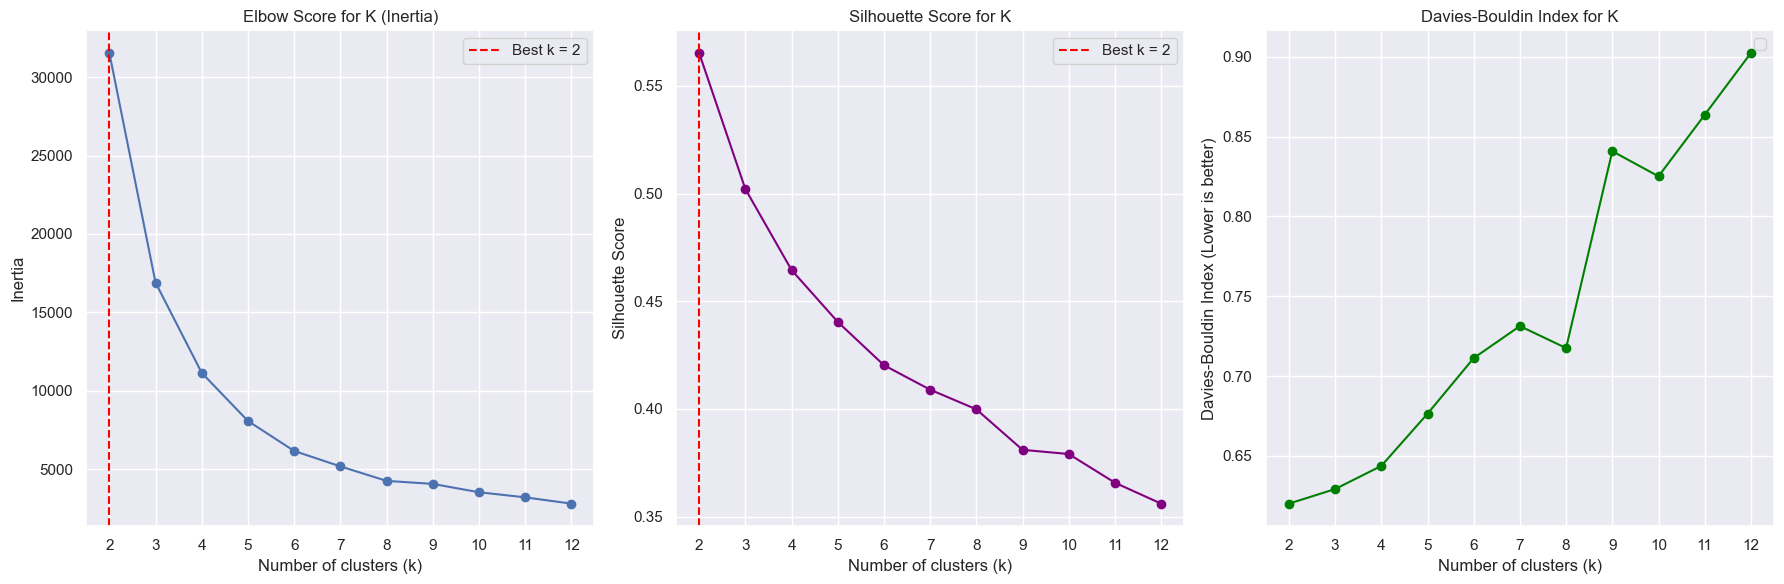

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
davies_bouldin_scores = []

kmeans_value = range(2, 13)  # k from 2 to 12

for k in kmeans_value:
    kmeans = KMeans(n_clusters=k, max_iter=500, random_state=1)
    clusters = kmeans.fit_predict(data_pca)

    silhouette = silhouette_score(data_pca, clusters)
    silhouette_scores.append(silhouette)

    inertia.append(kmeans.inertia_)

    dbi = davies_bouldin_score(data_pca, clusters)
    davies_bouldin_scores.append(dbi)

# Find best k based on max silhouette score
best_k_index = silhouette_scores.index(max(silhouette_scores))
best_k = kmeans_value[best_k_index]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(kmeans_value, inertia, marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.title("Elbow Score for K (Inertia)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(kmeans_value)
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(kmeans_value, silhouette_scores, color='purple', marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.title("Silhouette Score for K")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(kmeans_value)
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(kmeans_value, davies_bouldin_scores, color='green', marker='o')
#plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.title("Davies-Bouldin Index for K")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Index (Lower is better)")
plt.xticks(kmeans_value)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [50]:
kmeans = KMeans(n_clusters=4, max_iter=500, random_state=1)
label = kmeans.fit_predict(data_pca)

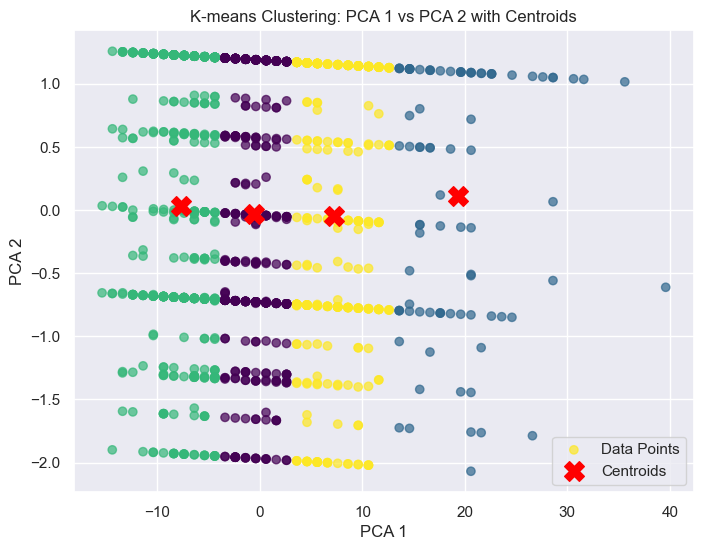

In [51]:
centroids = kmeans.cluster_centers_
df_pca['Cluster'] = label

plt.figure(figsize=(8, 6))

# Plot the clustered points
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', alpha=0.7, label='Data Points')

# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title('K-means Clustering: PCA 1 vs PCA 2 with Centroids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()


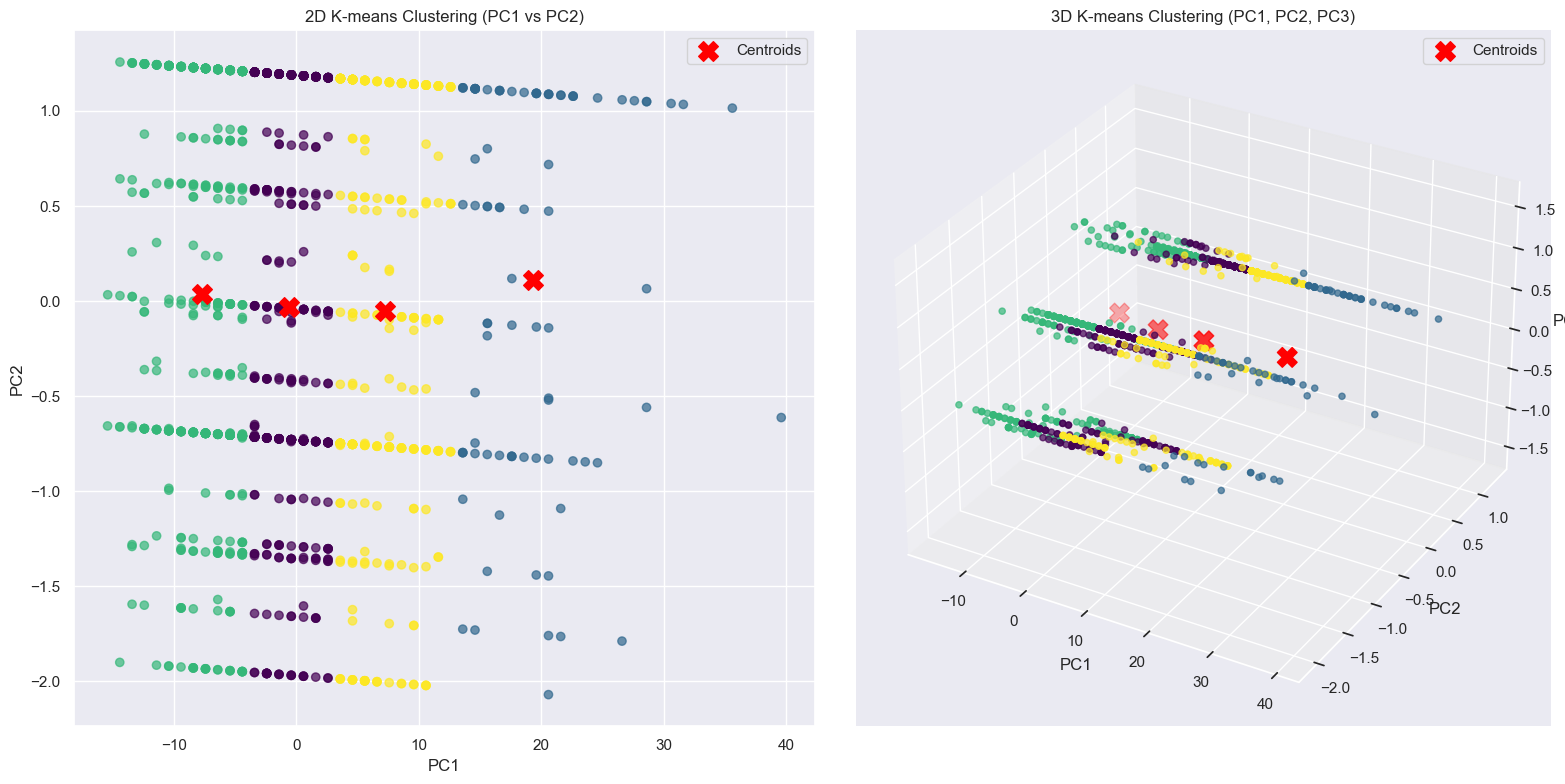

In [52]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

df_pca['Cluster'] = label
centroids = kmeans.cluster_centers_

# Set up a gridspec layout with equal width for both plots
fig = plt.figure(figsize=(16, 8))  # increased height for 3D better visibility
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])  # Equal widths for 2D and 3D

# 2D Plot
ax1 = fig.add_subplot(gs[0])
scatter = ax1.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', alpha=0.7)
ax1.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
ax1.set_title('2D K-means Clustering (PC1 vs PC2)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend()
ax1.grid(True)

# 3D Plot
ax2 = fig.add_subplot(gs[1], projection='3d')
scatter3d = ax2.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'], c=df_pca['Cluster'], cmap='viridis', alpha=0.7)
ax2.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c='red', s=200, marker='X', label='Centroids')
ax2.set_title('3D K-means Clustering (PC1, PC2, PC3)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.legend()

plt.tight_layout()
plt.show()


In [53]:
df_cluster = pd.read_csv('../processed_data/cleaned_data.csv')

In [54]:
df_cluster["Cluster"] = label

/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/4201107472.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  magma_cmap = cm.get_cmap('magma', 4)
/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/4201107472.py:14: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(data=df_processed, x=column, hue='Cluster', palette=magma_palette)
/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/4201107472.py:14: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(data=df_processed, x=column, hue='Cluster', palette=magma_palette)
/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/4201107472.py:14: UserWarning: The palette list has more values (4) than nee

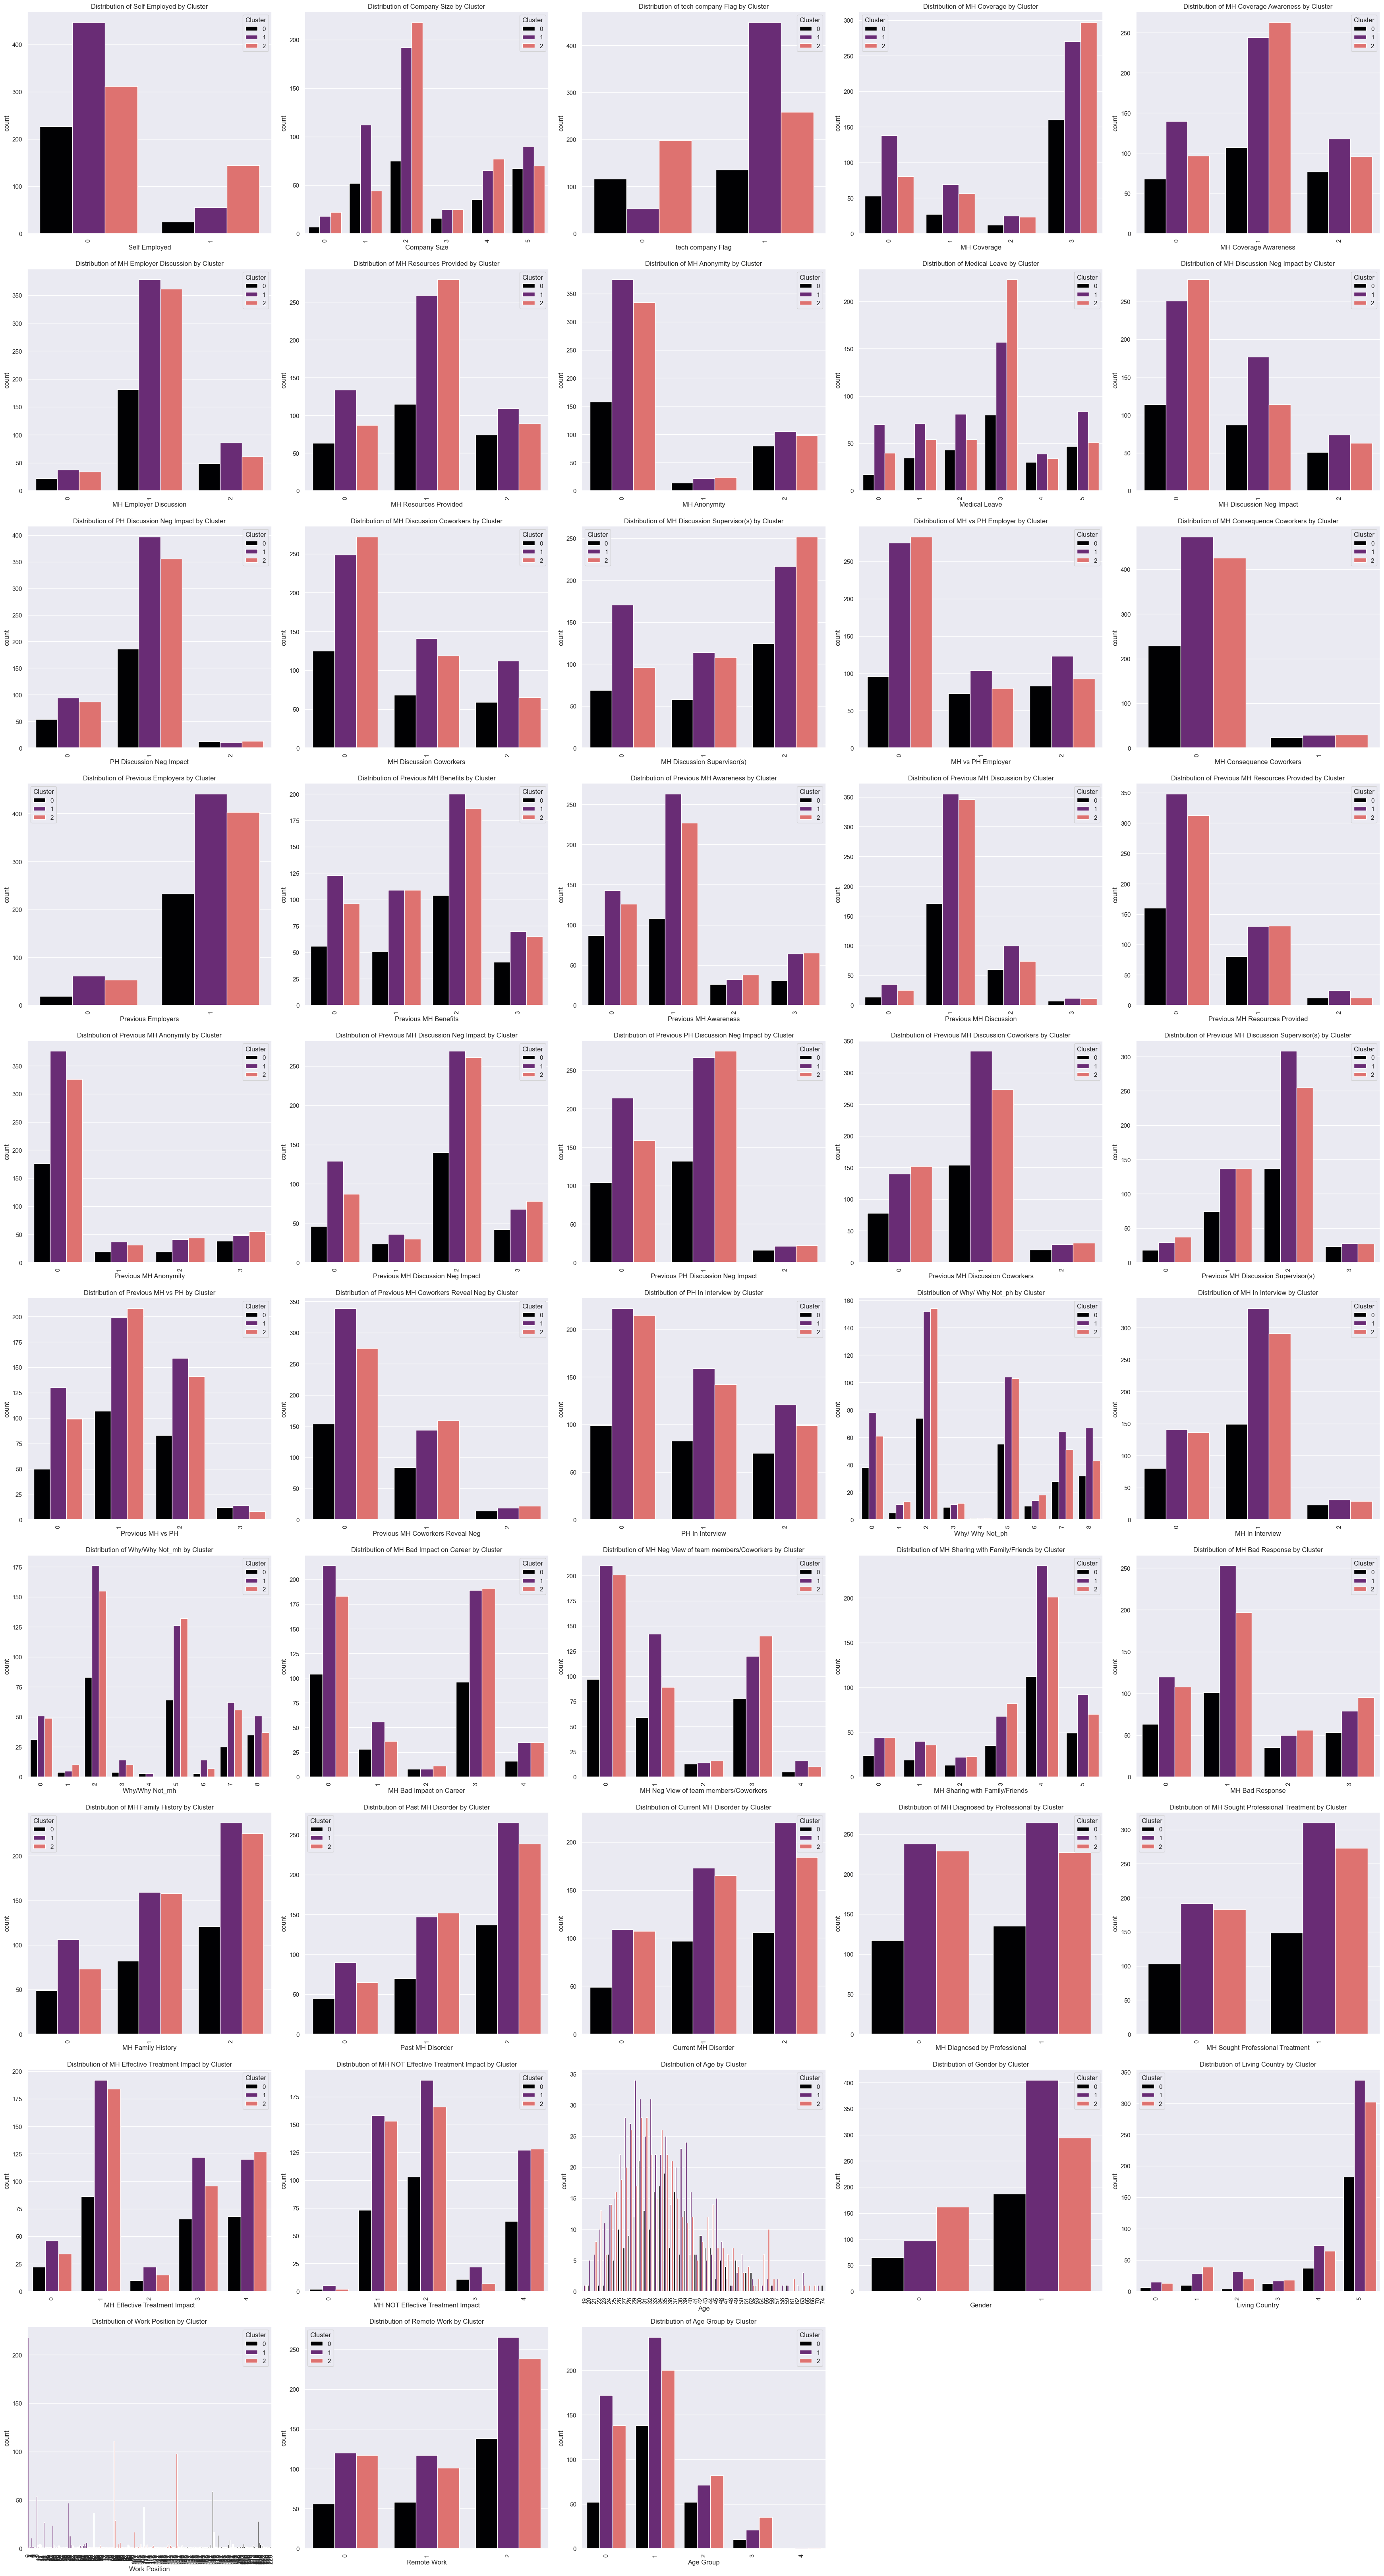

In [55]:
import matplotlib.cm as cm

# Generate 4 distinct colors from the 'magma' colormap
magma_cmap = cm.get_cmap('magma', 4)
magma_palette = [magma_cmap(i) for i in range(4)]  # RGBA tuples

plt.figure(figsize=(35, 65))

# Plot only columns that are in df_processed, excluding 'Cluster' and 'Working Country'
columns_to_plot = [col for col in df_processed.columns if col not in ['Cluster', 'Working Country']]

for i, column in enumerate(columns_to_plot):
    plt.subplot(10, 5, i + 1)
    sns.countplot(data=df_processed, x=column, hue='Cluster', palette=magma_palette)
    plt.xticks(rotation=90)
    plt.title(f'Distribution of {column} by Cluster')

plt.tight_layout()
#plt.savefig('images/cluster-bar-chart.png')
plt.show()


Initial clustering was too generic: The clusters formed didn’t highlight meaningful distinctions

Focus on important features: By selecting specific columns (variables) that seem more relevant or informative (e.g., mental health impact, family history, treatment), the clustering can be more targeted and insightful.

Better interpretation: With clusters built around meaningful features, it becomes easier to interpret, label, and act on the results,for example, understanding which group of employees is most at risk.

Actionable insights: This refined approach supports evidence-based decisions, like targeted HR interventions or wellness programs, instead of vague or overly broad conclusions.



## Cluster & Analyze

In [58]:
label_mapping = {
    0: "Senior MH Diagnosed",
    1: "Middle Aged No MH",
    2: "Young Adults MH Diagnosed",
    3: "MH Uncertain"
}

df_cluster['Cluster Profile'] = df_cluster['Cluster'].map(label_mapping)

df_pca.head()

,PC1,PC2,PC3,Cluster
0,4.600522,0.240506,-0.307040,3
1,-5.396077,1.213793,0.045878,2
2,3.591932,-1.062071,0.416251,3
3,8.603582,1.145974,0.115643,3
4,8.603582,1.145974,0.115643,3


In [59]:
def revert_gender_vals(col):
    unique_vals = set(col.unique())
    if unique_vals == {0, 1, 2}:
        mapping = {0: 'Male', 1: 'Female'}
        return col.map(mapping)
    else:
        return col  # If not the expected values, return the column as-is

df_cluster['Gender'] = revert_gender_vals(df_cluster['Gender'])


In [60]:

df_cl_0_senior_mh = df_cluster[df_cluster['Cluster'] == 0]
df_cl_1_mid_aged_no_mh = df_cluster[df_cluster['Cluster'] == 1]
df_cl_2_young_adults_mh = df_cluster[df_cluster['Cluster'] == 2]
df_cl_3_mh_uncertain = df_cluster[df_cluster['Cluster'] == 3]

df_cluster["Cluster"].value_counts()


Cluster
2    444
0    406
3    273
1     87
Name: count, dtype: int64

In [61]:

def create_pie_chart(data, column, title="Distribution"):
    """
    Creates a pie chart for a specified column in a dataset

    Parameters:
    data: DataFrame
    column: str (column name)
    title: str (chart title)
    """
    plt.figure(figsize=(6, 6))
    value_counts = data[column].value_counts()

    # Normalize for percentage display
    percentages = value_counts / value_counts.sum()

    # Use updated colormap method to avoid warning
    cmap = plt.colormaps.get_cmap("viridis")
    colors = cmap([i / len(percentages) for i in range(len(percentages))])

    # Create pie chart
    wedges, texts, autotexts = plt.pie(
        percentages,
        labels=value_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140
    )

    # Optional: Set label style
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    plt.title(title)
    plt.axis('equal')  # Keep pie chart circular
    plt.show()


In [62]:
def create_pie_chart(df, column, title="Pie Chart"):
    # Get value counts
    counts = df[column].value_counts()

    # Normalize to get percentages
    percentages = counts / counts.sum()

    # Use the updated colormap access
    cmap = plt.colormaps.get_cmap("viridis")
    colors = cmap([i / len(percentages) for i in range(len(percentages))])

    # Plot
    plt.figure(figsize=(6, 6))
    wedges, texts, autotexts = plt.pie(
        percentages,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors
    )

    # Set autopct text color to white and bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    plt.title(title)
    plt.axis('equal')  # Equal aspect ratio ensures pie is circular
    plt.show()


This cluster is characterized by individuals with ambiguous or non-disclosed mental health statuses. Members in this group often did not report clear information regarding past or current diagnoses and showed low engagement with treatment options. The cluster also displayed mixed demographic characteristics, making it harder to categorize compared to other groups.

In [98]:
def create_pie_chart(df, column, ax, title=''):
    cmap = plt.colormaps.get_cmap("viridis")
    data = df[column].value_counts()

    # Generate colors from the colormap
    colors = [cmap(i / len(data)) for i in range(len(data))]

    # Custom autopct function to set white text
    def white_autopct(pct):
        return f'{pct:.1f}%' if pct > 0 else ''

    wedges, texts, autotexts = ax.pie(
        data,
        labels=data.index,
        autopct=white_autopct,
        startangle=140,
        colors=colors
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    ax.set_title(title)


In [99]:
def create_count_plot_with_hue(df, x_col, hue_col, title, ax):
    # Get unique hue values and generate matching colors from viridis
    unique_hues = df[hue_col].dropna().unique()
    cmap = plt.colormaps.get_cmap("viridis")
    palette = {val: cmap(i / len(unique_hues)) for i, val in enumerate(unique_hues)}

    sns.countplot(data=df, x=x_col, hue=hue_col, ax=ax, palette=palette)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)


In [100]:
def generate_cluster_catalog_page(df_cluster, cluster_num, label_mapping):
    cluster_label = label_mapping[cluster_num]
    df = df_cluster[df_cluster['Cluster'] == cluster_num]

    fig, axs = plt.subplots(3, 3, figsize=(22, 18))
    fig.suptitle(f"📊 Cluster {cluster_num}: {cluster_label}", fontsize=20, weight='bold')

    axs = axs.flatten()

    create_pie_chart(df, 'Gender', axs[0], title="Gender distribution")
    create_count_plot_with_hue(df, 'Current MH Disorder', 'Gender', "MH based on Gender", axs[1])
    create_count_plot_with_hue(df, 'MH Family History', 'MH Sharing with Family/Friends',
                               "Family history vs MH sharing", axs[2])
    create_count_plot_with_hue(df, 'MH Discussion Neg Impact', 'MH Coverage Awareness',
                               "Coverage vs Career Impact", axs[3])
    create_count_plot_with_hue(df, 'MH Discussion Neg Impact', 'Previous MH Discussion Neg Impact',
                               "Past vs Current MH Discussion", axs[4])
    create_count_plot_with_hue(df, 'MH Discussion Coworkers', 'MH Discussion Supervisor(s)',
                               "Comfort with Coworkers vs Supervisors", axs[5])
    create_pie_chart(df, 'PH In Interview', axs[6], title="MH in Job Interview")
    create_count_plot_with_hue(df, 'MH Consequence Coworkers', 'MH Neg View of team members/Coworkers',
                               "Coworker Consequences vs Perception", axs[7])
    create_count_plot_with_hue(df, 'MH Effective Treatment Impact', 'MH NOT Effective Treatment Impact',
                               "Treatment Effectiveness", axs[8])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f'cluster_{cluster_num}_catalog.png', dpi=300)
    plt.show()


/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/1723081242.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/1723081242.py:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig(f'cluster_{cluster_num}_catalog.png', dpi=300)
/Users/oumaymabamoh/miniconda3/envs/mindstate-analyzer__/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


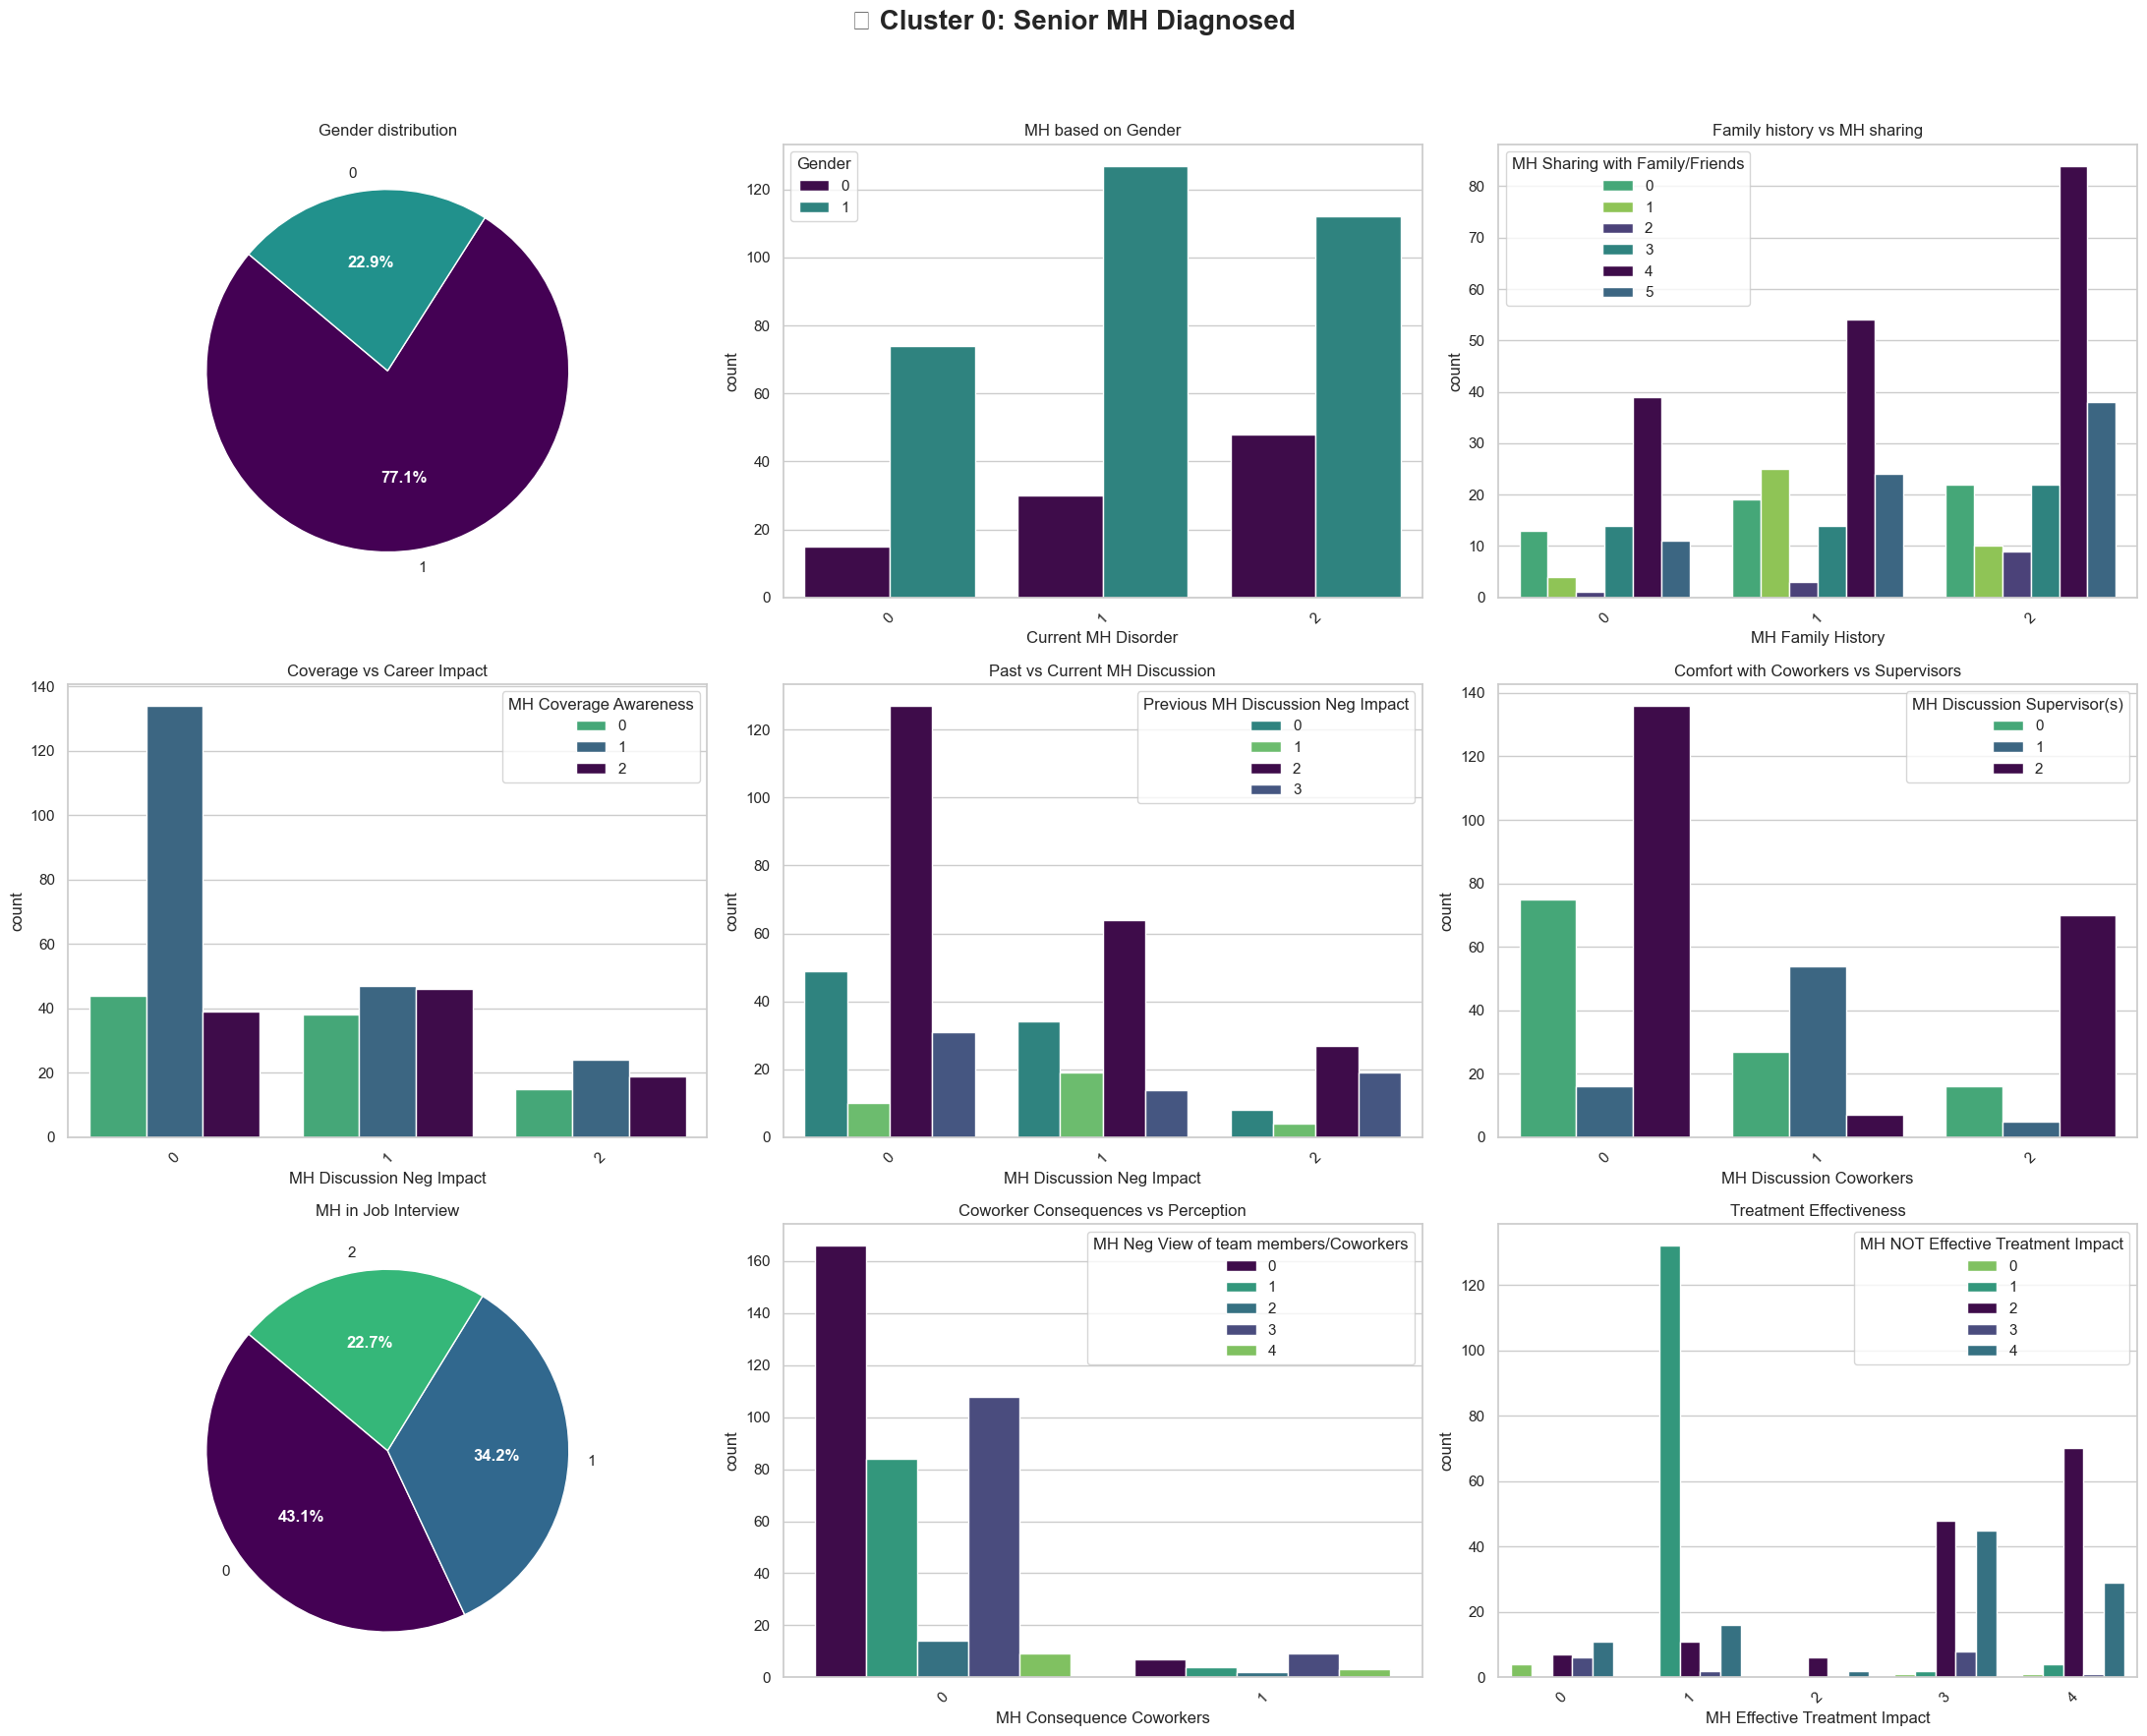

/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/1723081242.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/1723081242.py:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig(f'cluster_{cluster_num}_catalog.png', dpi=300)
/Users/oumaymabamoh/miniconda3/envs/mindstate-analyzer__/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


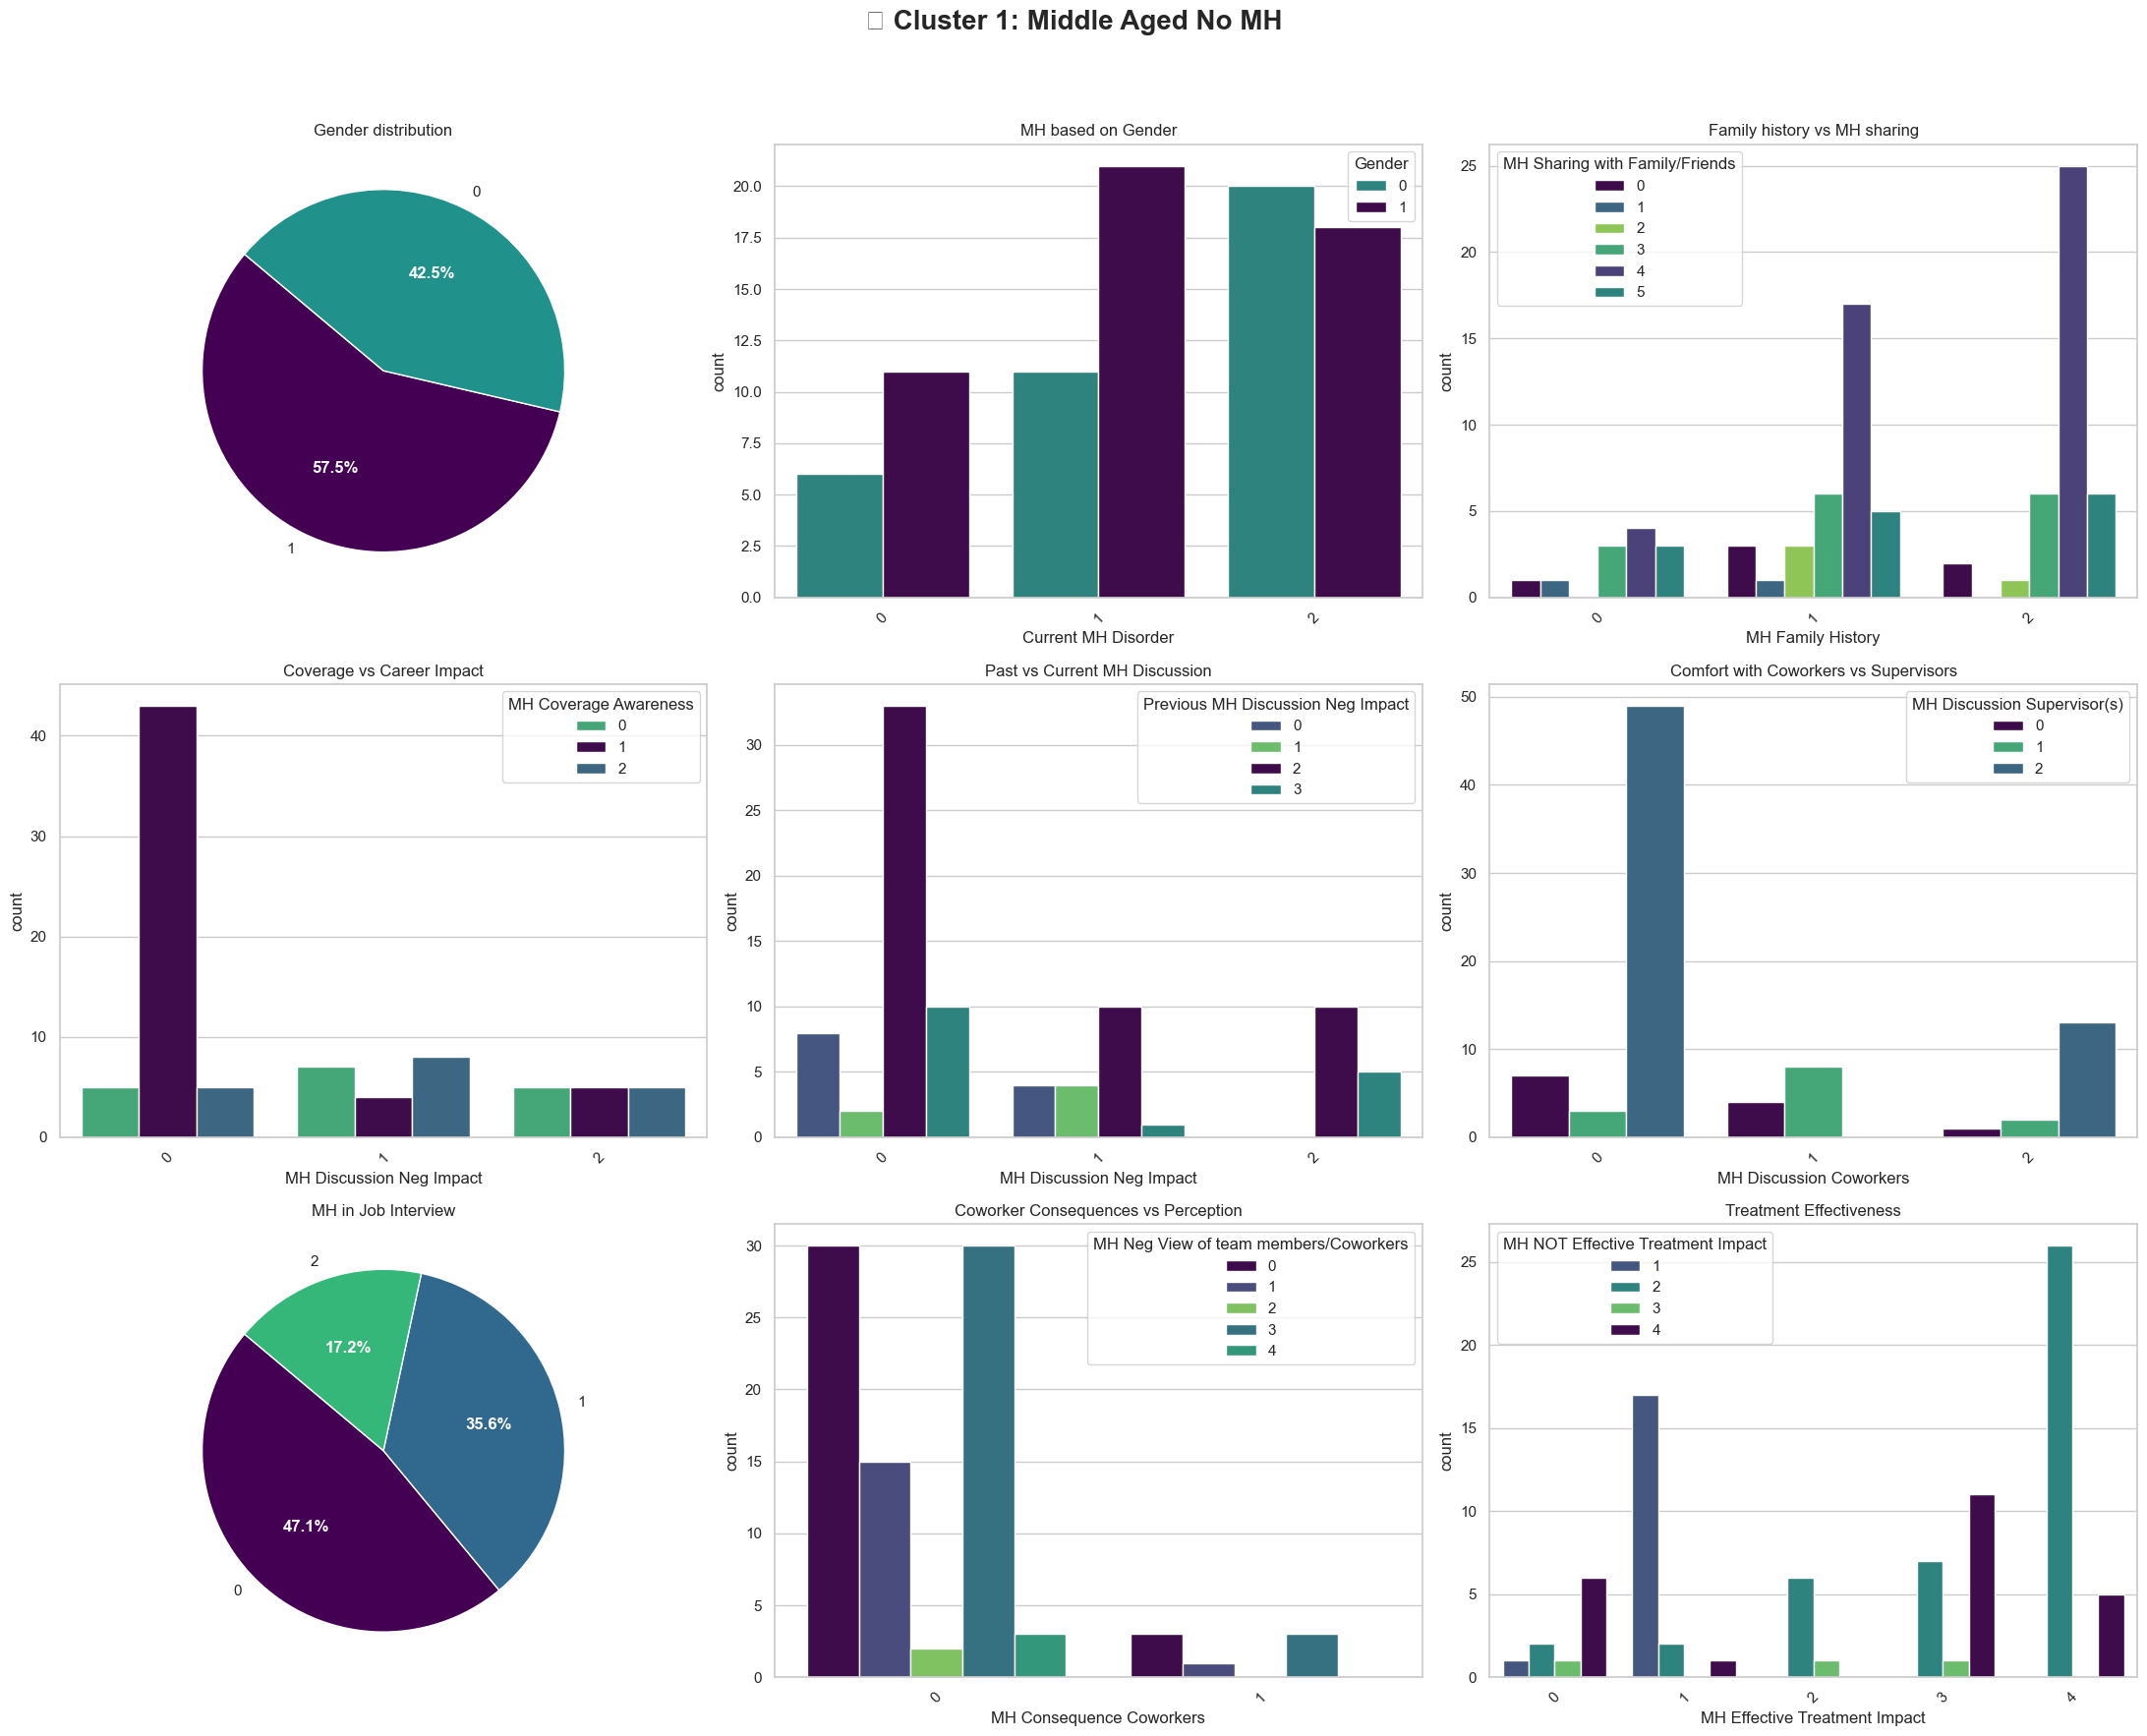

/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/1723081242.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/1723081242.py:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig(f'cluster_{cluster_num}_catalog.png', dpi=300)
/Users/oumaymabamoh/miniconda3/envs/mindstate-analyzer__/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


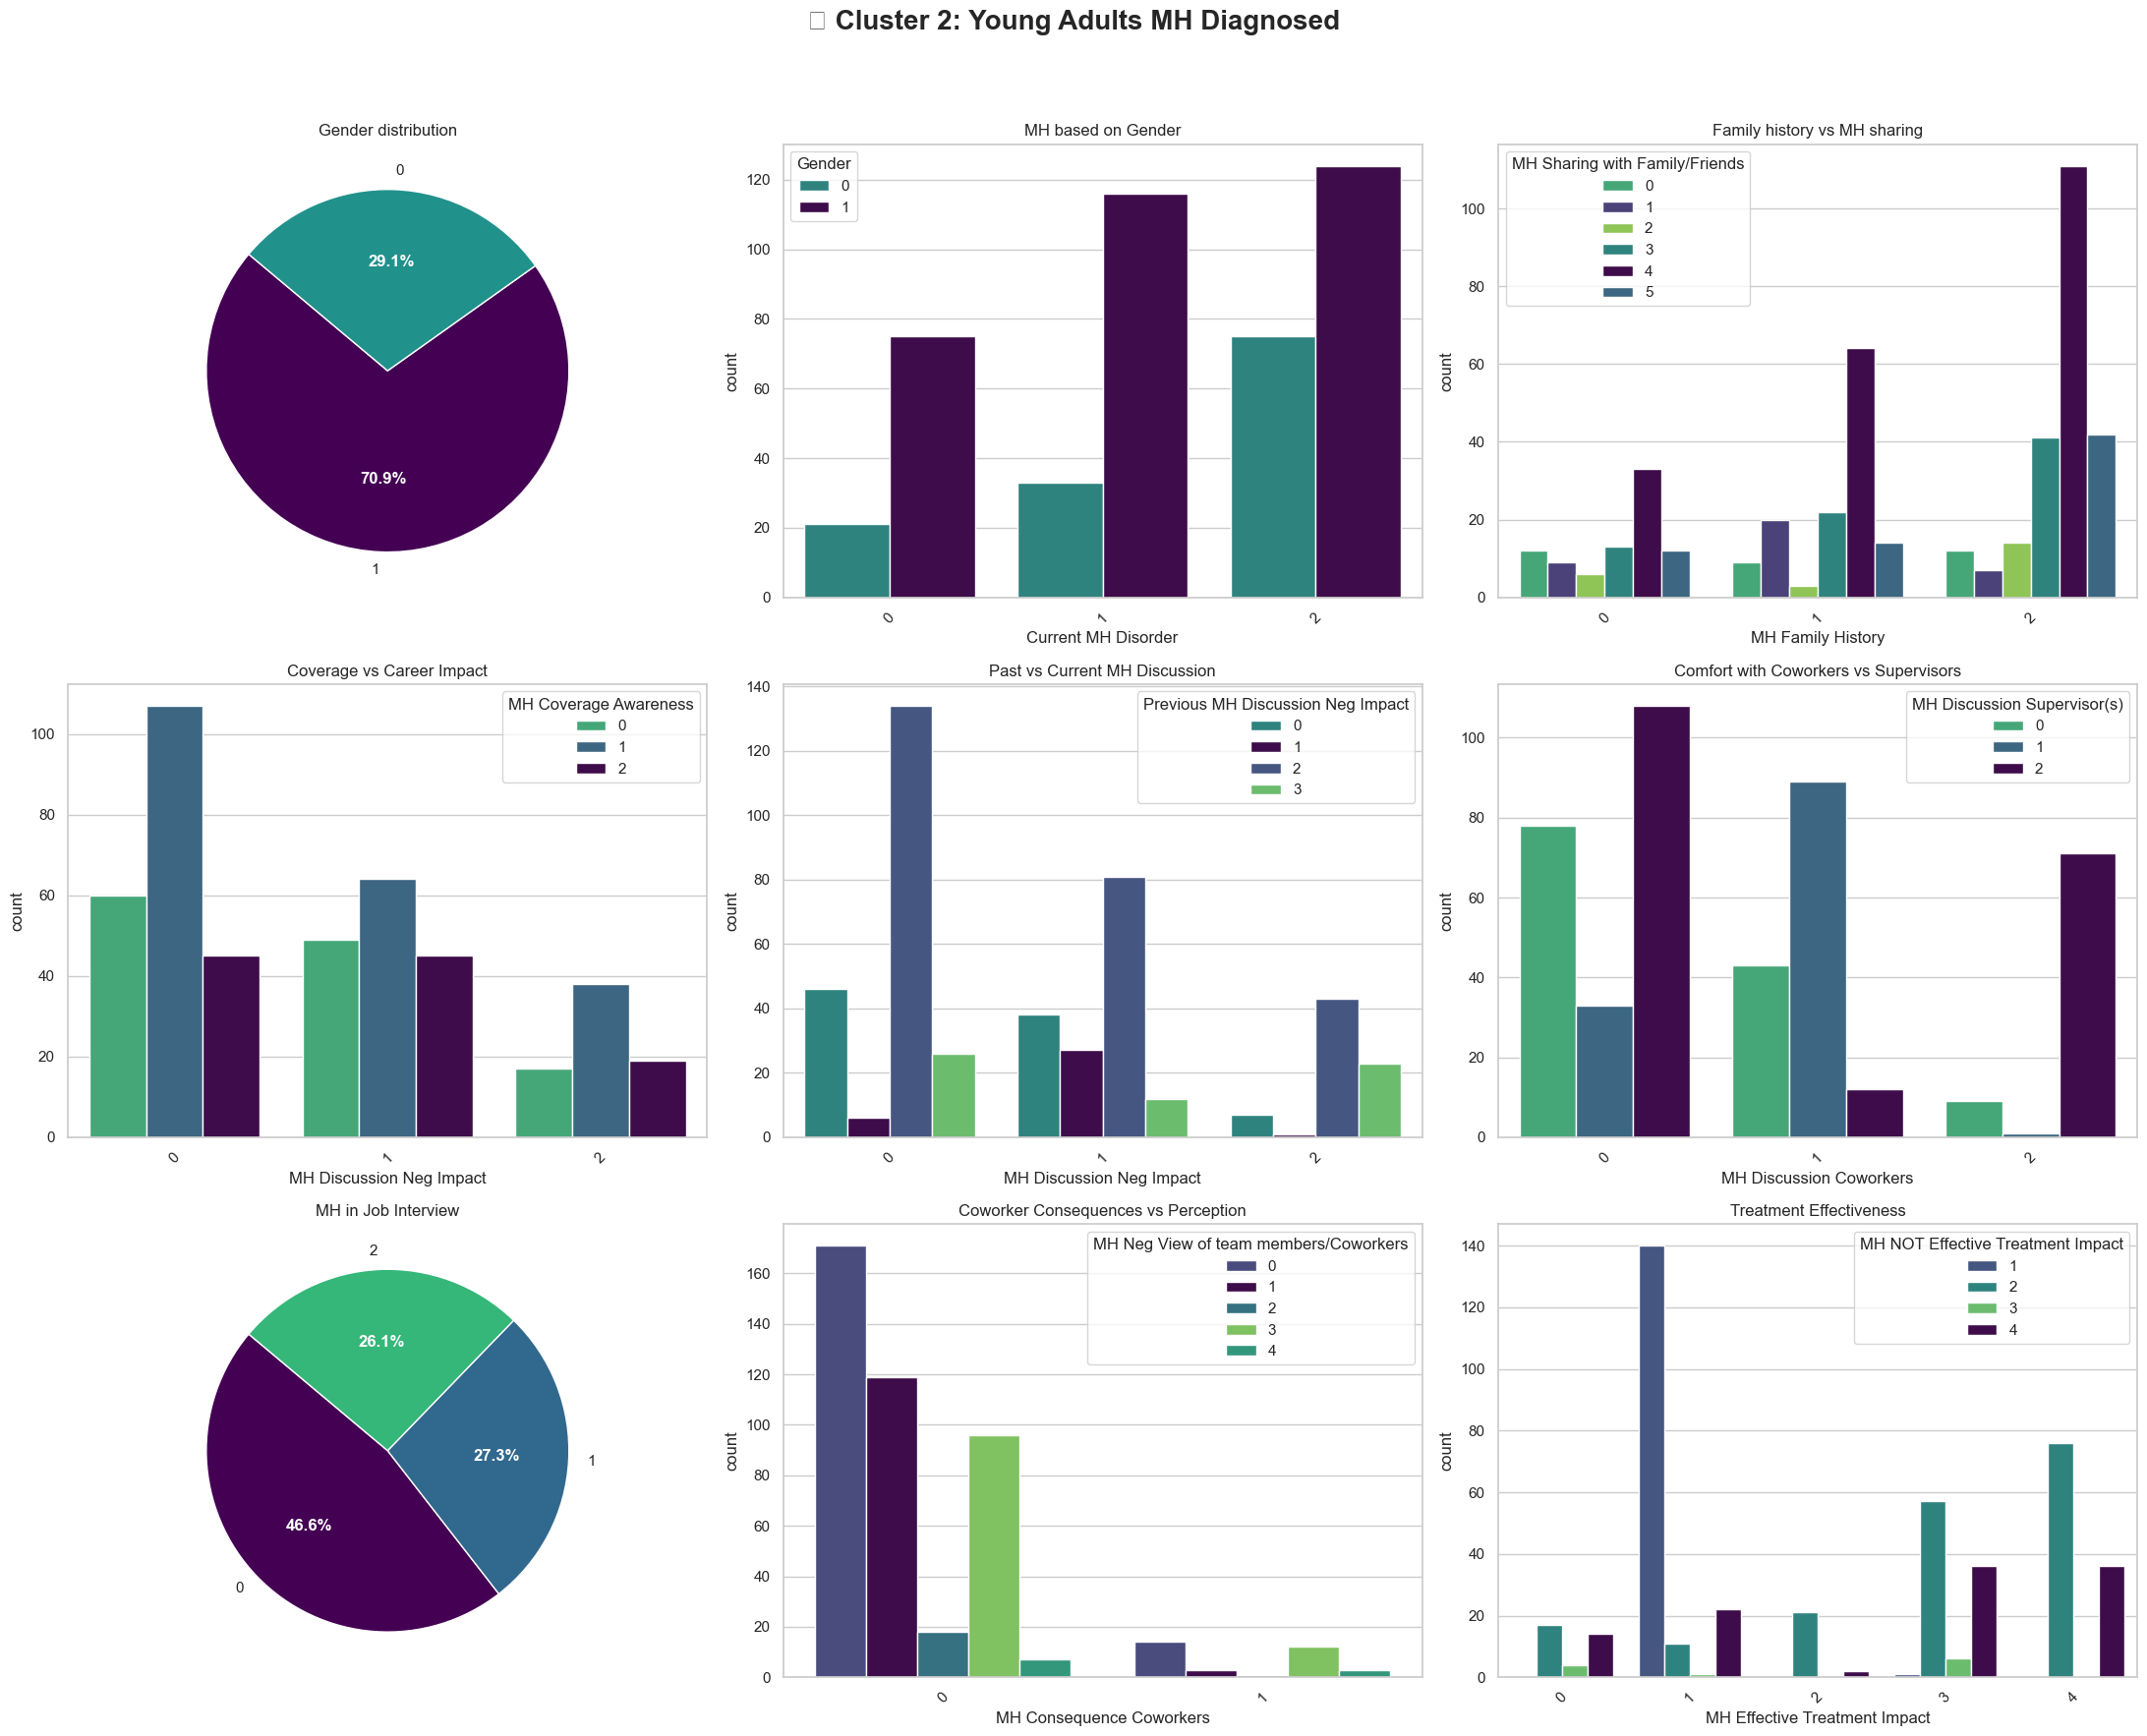

/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/1723081242.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/var/folders/tz/36qz0vtn4rb0h9dh9ghf_dpr0000gp/T/ipykernel_3457/1723081242.py:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig(f'cluster_{cluster_num}_catalog.png', dpi=300)
/Users/oumaymabamoh/miniconda3/envs/mindstate-analyzer__/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


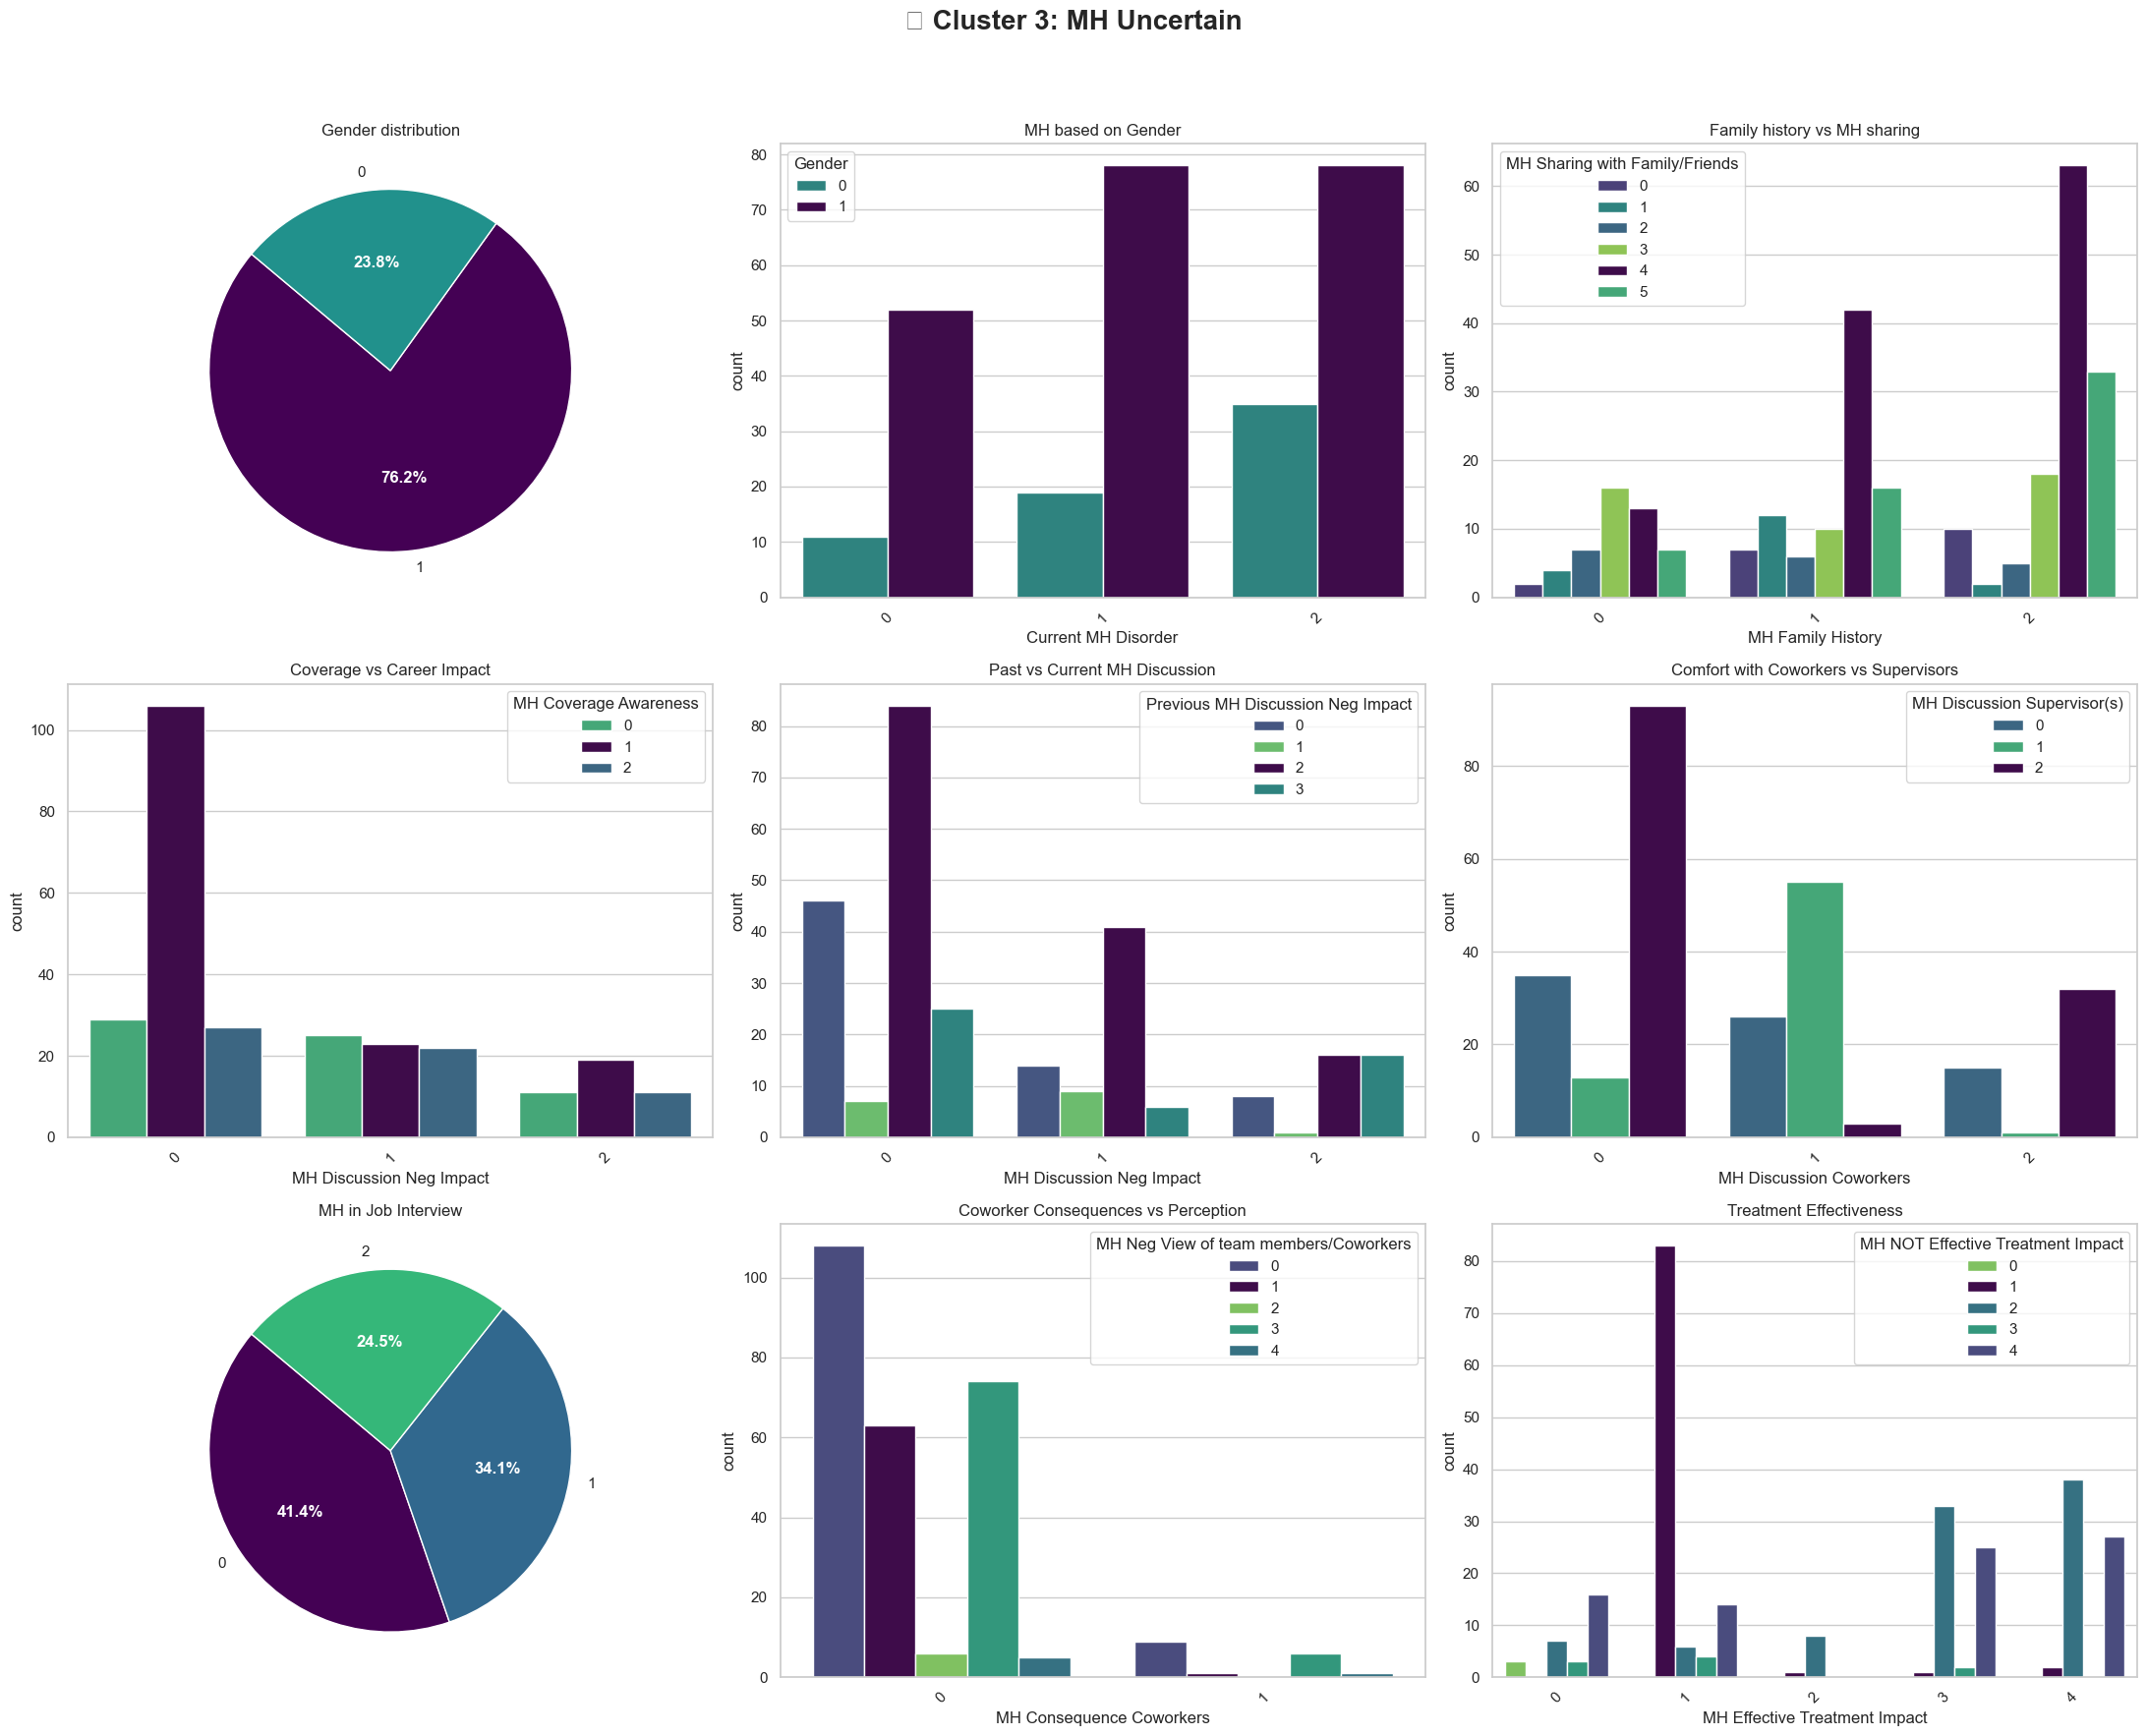

In [101]:
for cluster_num in range(4):  # if you have 4 clusters
    generate_cluster_catalog_page(df_cluster, cluster_num, label_mapping)
